# Reaction-Diffusion Model (Initial Coding task) (Subrata T) (phase-2)

## 0. Computational Environment (Thanks to UN Chicago)

| System | CPU | GPU | C / C++ |
|---|---|---|---|
| Linux / x86_64 | 128 cores | NVIDIA A100-SXM4-40GB | GCC / G++ |

| Scientific | Numerical / ML | Parallel | Build |
|---|---|---|---|
| NumPy · SciPy · SymPy | Scikit-learn · JAX · Numba | OpenMPI · MPI4Py · Dask | CMake · Make · Ninja |

| Data | Visualization | Optimization | Python / CUDA |
|---|---|---|---|
| HDF5 · Zarr · PyArrow | Matplotlib · IPyMPL | LMFIT | 3.11 · PyTorch CUDA 12.1 |

## 1. Objective

The objective of this task is to:

1. **Extract and isolate the Reaction–Diffusion (RD) model** and its governing equations from Part I of the assigned paper/material.
2. **Implement the RD equations numerically in C**, including hydrogen diffusion and interface trap-generation/recovery kinetics.
3. **Use the material parameters, device geometry, and physical constants specified in the assigned material** to perform the simulation.
4. **Generate stress and recovery characteristics** of the trap density and analyze their time dependence.
5. **Validate the numerical implementation** by comparing the simulated behavior with the expected behavior of the RD model described in the assigned material.

## Updated code from last run

In [1]:
#include <stdio.h>
#include <stdlib.h>
#include <math.h>

// Added the missing Thomas Algorithm solver so the code compiles and runs!
int solve_tridiagonal(int n, double *a, double *b, double *c, double *rhs, double *x) {
    double *c_prime = (double *)malloc(n * sizeof(double));
    double *d_prime = (double *)malloc(n * sizeof(double));
    if (!c_prime || !d_prime) return 0;
    
    c_prime[0] = c[0] / b[0];
    d_prime[0] = rhs[0] / b[0];
    for (int i = 1; i < n; i++) {
        double m = b[i] - a[i] * c_prime[i - 1];
        c_prime[i] = c[i] / m;
        d_prime[i] = (rhs[i] - a[i] * d_prime[i - 1]) / m;
    }
    x[n - 1] = d_prime[n - 1];
    for (int i = n - 2; i >= 0; i--) x[i] = d_prime[i] - c_prime[i] * x[i + 1];
    
    free(c_prime); free(d_prime);
    return 1;
}

// We will do the actual process...

#define NX_IL 300
#define NX_HK 1000

int main()
{
    // define constants
    const double kB = 8.617333262e-5;
    const double T = 125.0 + 273.15; // check for different temperature
    const double kT = kB * T;

    // Check what are the exact values? (assumptions but is it valid?)
    const double L_IL = 1.0e-7;
    const double L_HK = 1.5e-7; //(AS per suggetion)
    const double delta = 1.5e-8;

    const double dx_IL = L_IL / NX_IL;
    const double dx_HK = L_HK / NX_HK;

    const double N01 = 5.0e12; // directly used from book
    const double N02 = 5.0e13;

    const double KR1 = 5.0e-6 * exp(-0.12 / kT);
    const double KF2 = 5.75e3 * exp(-0.235 / kT);
    const double KR2 = 7.5e-4 * exp(-0.20 / kT);

    // Two species here, so each has its own D0 and Ea.
    // need to note that these are NOT the final D values.
    // Temperature comes through the Arrhenius factor.
    const double DH_IL = 2.0e-2 * exp(-0.20 / kT);
    const double DH2_HK = 9.5e-8 * exp(-0.50 / kT);

    // --- PROFF UPDATE: Correct NBTI Electrostatics ---
    // Replaced hardcoded EOX = 7.0 with actual calculation based on VG
    const double VG = -1.5; 
    const double V_fb = -1.0;
    const double psi_s = -0.8;
    const double V_ox = fabs(VG - V_fb - psi_s); 
    const double EOX = (V_ox / (1.0e-7 + 1.5e-7 * (4.0 / 20.0))) / 1.0e6;
    // -------------------------------------------------

    const double Gamma0 = 0.38; //check it
    const double alpha = 1.2;

    // For planar MOSFET. Need to check why A = 7.
    const double S_lock = 7.0;

    // Calculate the field/temperature dependent part first.
    double Gamma_E = Gamma0 +(alpha * 0.01) / kT;

    // KF1 is different from the other rates because it also depends
    // on the stress electric field and D1 process parameters. 
    double KF1_stress = 0.22 * exp(EOX * Gamma_E) * exp(-0.40 / kT);

    // H  -> current atomic-H concentration profile
    // H_prev -> concentration profile from previous timestep
    double H[NX_IL] = {0.0};
    double H_prev[NX_IL] = {0.0};

    // Same idea for molecular H2 in the High-K part.
    double H2[NX_HK] = {0.0};
    double H2_prev[NX_HK] = {0.0};

    // Now we create coefficient arrays for the tridiagonal systems.
    // These will be filled before calling the solver.
    double a_H[NX_IL];
    double b_H[NX_IL];
    double c_H[NX_IL];
    double rhs_H[NX_IL];

    double a_H2[NX_HK];
    double b_H2[NX_HK];
    double c_H2[NX_HK];
    double rhs_H2[NX_HK];

    // initial generated trap density.
    // this is initial condition assumption for the stress simulation.
    // N01 and N02 are still finite precursor populations. might be associtaed with some parameters check it.
    double NIT1 = 0.0;
    double NIT2 = 0.0;

    double t = 0.0;       // current simulation time
    double dt = 1.0e-9;   // start small; later we increase dt

    const double t_stress = 100000000.0;
    const double t_recov = 100000000.0;

    // Only for printing results at roughly logarithmic time intervals.
    double print_target = 1.0e-4;

    //Print some values
    FILE *fp = fopen("rd_results.csv", "w");

    if (fp == NULL) {
        fprintf(stderr, "ERROR: Could not open rd_results.csv\n");
        return EXIT_FAILURE;
    }

    // --- PROFF UPDATE: Added H and H2 to the prints ---
    fprintf(fp, "Phase,Time,NIT1,NIT2,Total_NIT,Atomic_H_Int,Mol_H2_Gate\n");
    printf("=== PHASE 1: STRESS " "(V_G = -1.5V, T = 125.0 C) ===\n" );
    printf( "%-12s %-16s %-16s %-16s %-16s %-16s\n", "Time(s)","NIT_1(/cm2)", "NIT_2(/cm2)", "Total_NIT", "H[0]", "H2_Gate");

    // Lets START STRESS
    while (t < t_stress) {

        // have to make sure the last step ends exactly at t_stress.
        if (t + dt > t_stress)
            dt = t_stress - t;
        // save the old concentration profiles before calculating the new timestep.
        for (int i = 0; i < NX_IL; i++)
            H_prev[i] = H[i];
        for (int i = 0; i < NX_HK; i++)
            H2_prev[i] = H2[i];

        // also keep the previous trap densities for this timestep.
        double NIT1_prev = NIT1;
        double NIT2_prev = NIT2;

        // a few iterations are used because H, H2 and NIT are coupled.
        for (int iter = 0; iter < 400; iter++) {
            // first calculate the reaction terms at both interfaces.
            double Denom1 =1.0 + dt * KF1_stress + dt * KR1 * H[0];
            double Denom2 = 1.0 + dt * KF2 * H[NX_IL - 1] + dt * KR2 * H2[0];

            // Diffusion coefficient for the dimensionless
            // finite-difference parameter r_H.
            double r_H = DH_IL * dt / (dx_IL * dx_IL);
            double r_H_delta = DH_IL * dt / ((delta / 2.0) * dx_IL);

            // now build the tridiagonal system for atomic H.
            for (int i = 0; i < NX_IL; i++) {
                if (i == 0) {
                    // Interface 1 boundary.
                    a_H[0] = 0.0;
                    b_H[0] = 1.0 + r_H_delta + (dt / (delta / 2.0)) * (KR1 * NIT1_prev) / Denom1;
                    c_H[0] = -r_H_delta;
                    rhs_H[0] = H_prev[0] +(dt / (delta / 2.0)) *(KF1_stress * (N01 - NIT1_prev)) /Denom1;
                } else if (i == NX_IL - 1) {
                    // Interface 2 boundary.
                    a_H[i] = -r_H_delta;
                    b_H[i] = 1.0 + r_H_delta + (dt / (delta / 2.0)) * (KF2 * (N02 - NIT2_prev)) / Denom2;
                    c_H[i] = 0.0;
                    rhs_H[i] =H_prev[i] +(dt / (delta / 2.0)) *(KR2 * NIT2_prev * H2[0]) / Denom2;
                } else {
                    // Normal diffusion node.
                    a_H[i] = -r_H;
                    b_H[i] = 1.0 + 2.0 * r_H;
                    c_H[i] = -r_H;
                    rhs_H[i] = H_prev[i];
                }
            }
            // Now Solve for the new atomic-H concentration profile.
            if (!solve_tridiagonal(NX_IL, a_H, b_H, c_H, rhs_H,H)) {
                fprintf(stderr,"ERROR: H solver failed during stress.\n");
                fclose(fp);
                return EXIT_FAILURE;
            }
            // Now lets do the same thing for H2.
            double r_H2 = DH2_HK * dt / (dx_HK * dx_HK);
            double r_H2_delta = DH2_HK * dt / ((delta / 2.0) * dx_HK);

            // Build the H2 tridiagonal system.
            for (int i = 0; i < NX_HK; i++) {
                if (i == 0) {
                    // H2 starts from the second-interface side.
                    a_H2[0] = 0.0;
                    b_H2[0] = 1.0 + r_H2_delta +(dt / (delta / 2.0)) *(KR2 * NIT2_prev) / Denom2;
                    c_H2[0] = -r_H2_delta;
                    rhs_H2[0] = H2_prev[0] + (dt / (delta / 2.0)) * (KF2 * (N02 - NIT2_prev) * H[NX_IL - 1]) / Denom2;
                } else if (i == NX_HK - 1) {
                    // Far end of the H2 diffusion domain.
                    
                    // --- PROFF UPDATE: Activated Reflective Boundary ---
                    a_H2[i] = 0.0;
                    b_H2[i] = 1.0;
                    c_H2[i] = 0.0;
                    rhs_H2[i] = 0.0;
                    //reflective
                    // a_H2[i] = -2.0 * r_H2;
                    // b_H2[i] = 1.0 + 2.0 * r_H2;
                    // c_H2[i] = 0.0;
                    // rhs_H2[i] = H2_prev[i];
                    // ---------------------------------------------------
                    
                } else {
                    // Normal H2 diffusion node.
                    a_H2[i] = -r_H2;
                    b_H2[i] = 1.0 + 2.0 * r_H2;
                    c_H2[i] = -r_H2;
                    rhs_H2[i] = H2_prev[i];
                }
            }

            // Solve for the new H2 concentration profile.
            if (!solve_tridiagonal( NX_HK, a_H2, b_H2, c_H2, rhs_H2, H2)) {
                fprintf(stderr,"ERROR: H2 solver failed during stress.\n");
                fclose(fp);
                return EXIT_FAILURE;
            }

            // Now update the two interface trap densities.
            NIT1 =NIT1_prev + dt * (KF1_stress * (N01 - NIT1_prev) - KR1 * NIT1_prev * H[0]) /Denom1;
            NIT2 = NIT2_prev + dt * (KF2 *(N02 - NIT2_prev) * H[NX_IL - 1] - KR2 * NIT2_prev * H2[0]) / Denom2;

            // trap densities should be physically bounded.
            if (NIT1 < 0.0) NIT1 = 0.0;
            if (NIT1 > N01) NIT1 = N01;
            if (NIT2 < 0.0) NIT2 = 0.0;
            if (NIT2 > N02) NIT2 = N02;
        }

        // Move to the next stress time.
        t += dt;

        // Increase timestep slowly after the early-time region.
        // if (dt < 2.0)
        //     dt *= 1.05;
        dt *= 1.05;
        if (dt > 1.0e5) 
            dt = 1.0e5;
        // print only selected times so the output stays manageable.
        if (t >= print_target || t >= t_stress) {
            printf("%-12.4e %-16.4e %-16.4e %-16.4e %-16.4e %-16.4e\n", t, NIT1, NIT2, NIT1 + NIT2, H[0], H2[NX_HK-1]);
            fprintf(fp,"Stress,%e,%e,%e,%e,%e,%e\n",t,NIT1,NIT2, NIT1 + NIT2, H[0], H2[NX_HK-1]);
            print_target *= 10.0;
        }
    }

    //  RECOVERY 
    printf("\n=== PHASE 2: RECOVERY " "(V_GREC = 0V, T = 125.0 C) ===\n");
    printf("%-12s %-16s %-16s %-16s %-16s %-16s\n", "t_rec(s)","NIT_1(/cm2)","NIT_2(/cm2)","Total_NIT", "H[0]", "H2_Gate");

    double t_rec = 0.0;
    dt = 1.0e-9;
    print_target = 1.0e-4;

    // START RECOVERY smilar way
    while (t_rec < t_recov) {
        if (t_rec + dt > t_recov)
            dt = t_recov - t_rec;

        // Again save the previous state before solving
        // the next recovery timestep.
        for (int i = 0; i < NX_IL; i++)
            H_prev[i] = H[i];
        for (int i = 0; i < NX_HK; i++)
            H2_prev[i] = H2[i];

        double NIT1_prev = NIT1;
        double NIT2_prev = NIT2;

        // Check how H2 diffusion changes during recovery.
        double DH2_HK_rec = DH2_HK /(1.0 +S_lock *(t_rec / t_stress));

        // H, H2 and trap densities are still coupled here.
        for (int iter = 0; iter < 400; iter++) {
            double Denom1 =1.0 + dt * KR1 * H[0];
            double Denom2 =1.0 + dt * KR2 * H2[0];
            double r_H =DH_IL * dt / (dx_IL * dx_IL);

            double r_H_delta = DH_IL * dt / ((delta / 2.0) * dx_IL);

            // Build H system for recovery.
            for (int i = 0; i < NX_IL; i++) {
                if (i == 0) {
                    // interface 1- now mainly passivation.
                    a_H[0] = 0.0;
                    b_H[0] =1.0 + r_H_delta + (dt / (delta / 2.0)) *(KR1 * NIT1_prev) / Denom1;
                    c_H[0] = -r_H_delta;
                    rhs_H[0] = H_prev[0];
                } else if (i == NX_IL - 1) {
                    // interface 2 during recovery.
                    a_H[i] = -r_H_delta;
                    b_H[i] = 1.0 + r_H_delta;
                    c_H[i] = 0.0;
                    rhs_H[i] =H_prev[i] +(dt / (delta / 2.0)) *(KR2 * NIT2_prev * H2[0]) /Denom2;
                    
                } else {
                    a_H[i] = -r_H;
                    b_H[i] = 1.0 + 2.0 * r_H;
                    c_H[i] = -r_H;
                    rhs_H[i] = H_prev[i];
                }
            }

            if (!solve_tridiagonal(NX_IL,a_H,b_H,c_H,rhs_H,H)) 
            {
                fprintf(stderr, "ERROR: H solver failed during recovery.\n");
                fclose(fp);
                return EXIT_FAILURE;
            }

            // H2 diffusion during recovery.
            double r_H2 =DH2_HK_rec * dt /(dx_HK * dx_HK);
            double r_H2_delta = DH2_HK_rec * dt / ((delta / 2.0) * dx_HK);

            for (int i = 0; i < NX_HK; i++) {
                if (i == 0) {
                    a_H2[0] = 0.0;
                    b_H2[0] = 1.0 + r_H2_delta + (dt / (delta / 2.0)) * (KR2 * NIT2_prev) / Denom2;
                    c_H2[0] = -r_H2_delta;
                    rhs_H2[0] = H2_prev[0];
                } else if (i == NX_HK - 1) {
                    // Far boundary of H2 domain.
                    
                    // --- PROFF UPDATE: Activated Reflective Boundary ---
                    a_H2[i] = 0.0;
                    b_H2[i] = 1.0;
                    c_H2[i] = 0.0;
                    rhs_H2[i] = 0.0;

                    // Reflective / zero-flux far boundary.
                    // a_H2[i] = -2.0 * r_H2;
                    // b_H2[i] = 1.0 + 2.0 * r_H2;
                    // c_H2[i] = 0.0;
                    // rhs_H2[i] = H2_prev[i];
                    // ---------------------------------------------------
                    
                } else {
                    a_H2[i] = -r_H2;
                    b_H2[i] = 1.0 + 2.0 * r_H2;
                    c_H2[i] = -r_H2;
                    rhs_H2[i] = H2_prev[i];
                }
            }

            if (!solve_tridiagonal(NX_HK,a_H2,b_H2,c_H2,rhs_H2,H2)) 
            {
                fprintf(stderr,"ERROR: H2 solver failed during recovery.\n");
                fclose(fp);
                return EXIT_FAILURE;
            }

            // During recovery the reverse reactions reduce NIT.
            NIT1 = NIT1_prev + dt * (-KR1 * NIT1_prev * H[0]) /Denom1;
            NIT2 =NIT2_prev + dt *(-KR2 * NIT2_prev * H2[0]) / Denom2;

            //check  trap density should not become negative.
            if (NIT1 < 0.0) NIT1 = 0.0;
            if (NIT2 < 0.0) NIT2 = 0.0;
        }

        t_rec += dt;

        // if (dt < 2.0)
        //     dt *= 1.05;
        dt *= 1.05;
        if (dt > 1.0e5) 
            dt = 1.0e5;

        if (t_rec >= print_target || t_rec >= t_recov) {
            printf("%-12.4e %-16.4e %-16.4e %-16.4e %-16.4e %-16.4e\n",t_rec, NIT1,NIT2,NIT1 + NIT2, H[0], H2[NX_HK-1]);
            fprintf(fp,"Recovery,%e,%e,%e,%e,%e,%e\n",t_rec,NIT1,NIT2,NIT1 + NIT2, H[0], H2[NX_HK-1]);
            print_target *= 10.0;
        }
    }
    fclose(fp);
    return EXIT_SUCCESS;
}

In [2]:
// main()  This was ran for Reflective results are shown with plots

=== PHASE 1: STRESS (V_G = -1.5V, T = 125.0 C) ===
Time(s)      NIT_1(/cm2)      NIT_2(/cm2)      Total_NIT        H[0]             H2_Gate         
1.0211e-04   5.2317e+03       5.1203e+03       1.0352e+04       8.6833e+04       1.4036e-115     
1.0117e-03   5.1834e+04       4.8785e+04       1.0062e+05       8.6832e+04       1.5813e-20      
1.0022e-02   5.1344e+05       4.7816e+05       9.9160e+05       8.6822e+04       1.4747e+07      
1.0424e-01   5.3371e+06       4.9449e+06       1.0282e+07       8.6717e+04       9.1877e+12      
1.0326e+00   5.2543e+07       4.7530e+07       1.0007e+08       8.5796e+04       2.7574e+14      
1.0229e+01   4.9050e+08       4.4800e+08       9.3849e+08       8.5443e+04       2.8242e+15      
1.0025e+02   2.0043e+09       1.8627e+09       3.8670e+09       1.6276e+05       1.1843e+16      
1.0005e+03   2.0418e+09       1.8979e+09       3.9397e+09       1.6572e+05       1.2068e+16      
1.0000e+04   2.0418e+09       1.8979e+09       3.9397e+09       1.6

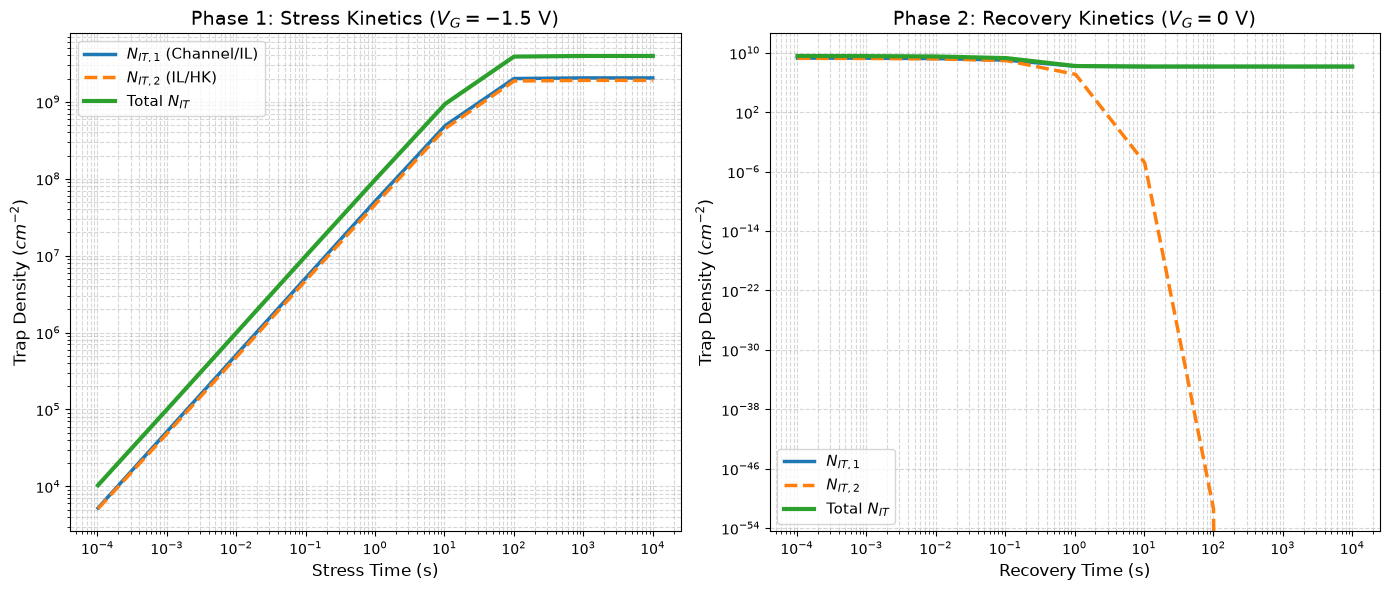

In [2]:
// main() //This was ran for Open sink results are shown below 

=== PHASE 1: STRESS (V_G = -1.5V, T = 125.0 C) ===
Time(s)      NIT_1(/cm2)      NIT_2(/cm2)      Total_NIT        H[0]             H2_Gate         
1.0211e-04   5.2317e+03       5.1203e+03       1.0352e+04       8.6833e+04       0.0000e+00      
1.0117e-03   5.1834e+04       4.8785e+04       1.0062e+05       8.6832e+04       0.0000e+00      
1.0022e-02   5.1344e+05       4.7816e+05       9.9160e+05       8.6822e+04       0.0000e+00      
1.0424e-01   5.3371e+06       4.9461e+06       1.0283e+07       8.6717e+04       0.0000e+00      
1.0326e+00   5.2543e+07       5.0288e+07       1.0283e+08       8.5737e+04       0.0000e+00      
1.0229e+01   4.9211e+08       4.9443e+08       9.8654e+08       7.7589e+04       0.0000e+00      
1.0025e+02   3.4894e+09       3.7040e+09       7.1934e+09       4.7180e+04       0.0000e+00      
1.0005e+03   1.5218e+10       1.7911e+10       3.3130e+10       1.8596e+04       0.0000e+00      
1.0000e+04   4.4979e+10       5.9726e+10       1.0470e+11       7.1

ERROR: received unknown message
Message type: usage_request


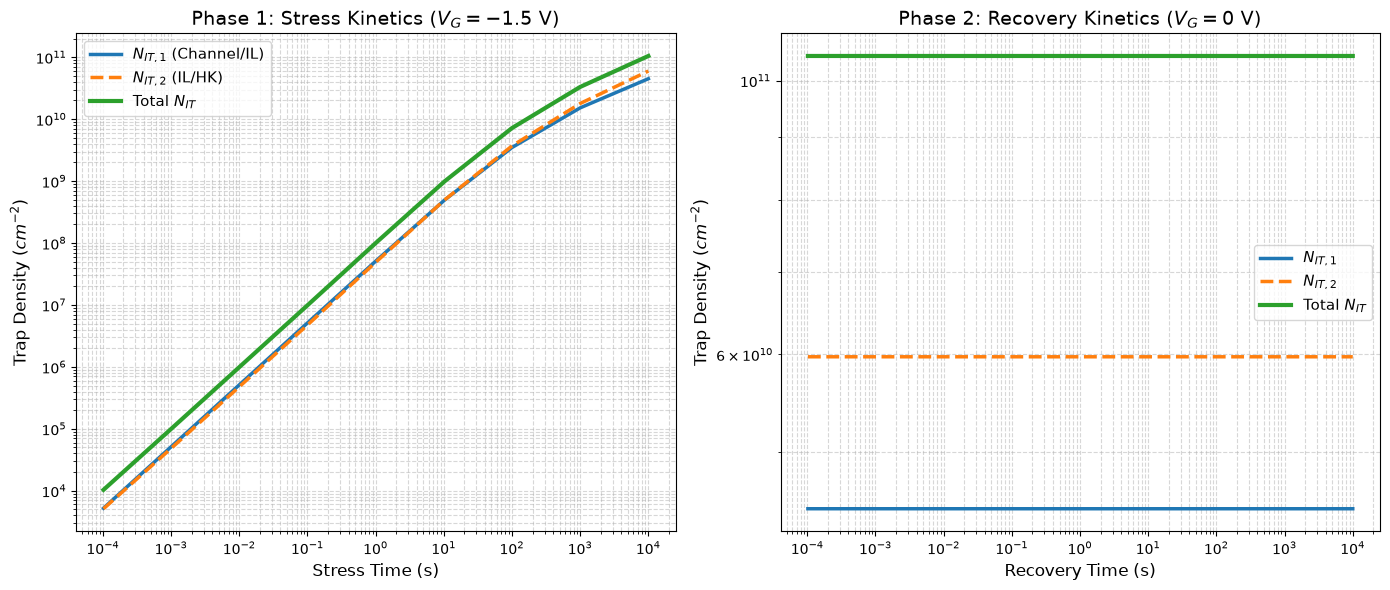

In [2]:
// main() //For long time 10^8s

=== PHASE 1: STRESS (V_G = -1.5V, T = 125.0 C) ===
Time(s)      NIT_1(/cm2)      NIT_2(/cm2)      Total_NIT        H[0]             H2_Gate         
1.0211e-04   5.2317e+03       5.1203e+03       1.0352e+04       8.6833e+04       0.0000e+00      
1.0117e-03   5.1834e+04       4.8785e+04       1.0062e+05       8.6832e+04       0.0000e+00      
1.0022e-02   5.1344e+05       4.7816e+05       9.9160e+05       8.6822e+04       0.0000e+00      
1.0424e-01   5.3371e+06       4.9461e+06       1.0283e+07       8.6717e+04       0.0000e+00      
1.0326e+00   5.2543e+07       5.0288e+07       1.0283e+08       8.5737e+04       0.0000e+00      
1.0229e+01   4.9211e+08       4.9443e+08       9.8654e+08       7.7589e+04       0.0000e+00      
1.0133e+02   3.5126e+09       3.7269e+09       7.2395e+09       4.7031e+04       0.0000e+00      
1.0038e+03   1.5178e+10       1.7702e+10       3.2879e+10       1.8616e+04       0.0000e+00      
1.0440e+04   4.5854e+10       5.9755e+10       1.0561e+11       7.0

ERROR: received unknown message
Message type: usage_request


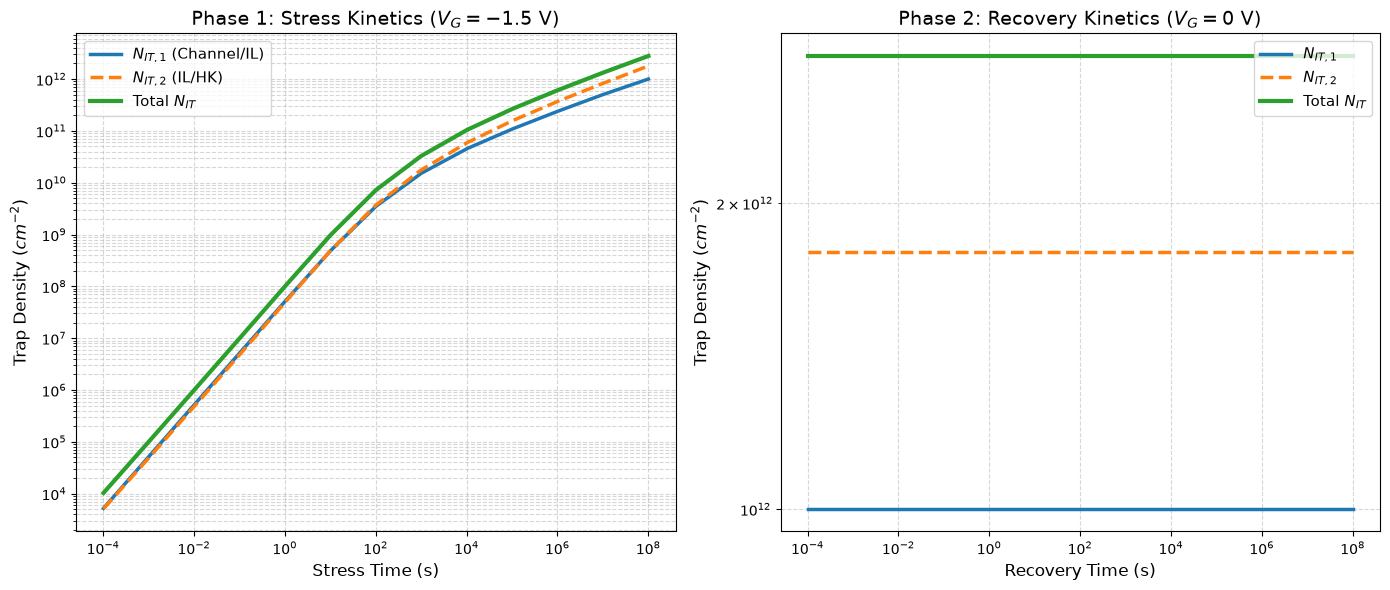

In [2]:
// main() //pcad iteration incresed from 4 to 400 (Notice the Nit values are becomming equal but Nit2 is greater than the other

=== PHASE 1: STRESS (V_G = -1.5V, T = 125.0 C) ===
Time(s)      NIT_1(/cm2)      NIT_2(/cm2)      Total_NIT        H[0]             H2_Gate         
1.0211e-04   5.2317e+03       5.2317e+03       1.0463e+04       8.6833e+04       0.0000e+00      
1.0117e-03   5.1834e+04       5.1834e+04       1.0367e+05       8.6832e+04       0.0000e+00      
1.0022e-02   5.1344e+05       5.1344e+05       1.0269e+06       8.6822e+04       0.0000e+00      
1.0424e-01   5.3371e+06       5.3371e+06       1.0674e+07       8.6718e+04       0.0000e+00      
1.0326e+00   5.2543e+07       5.2543e+07       1.0509e+08       8.5741e+04       0.0000e+00      
1.0229e+01   4.9211e+08       4.9211e+08       9.8423e+08       7.7577e+04       0.0000e+00      
1.0133e+02   3.5165e+09       3.5165e+09       7.0330e+09       4.6804e+04       0.0000e+00      
1.0038e+03   1.5472e+10       1.5472e+10       3.0945e+10       1.8083e+04       0.0000e+00      
1.0440e+04   4.9976e+10       4.9976e+10       9.9953e+10       6.4

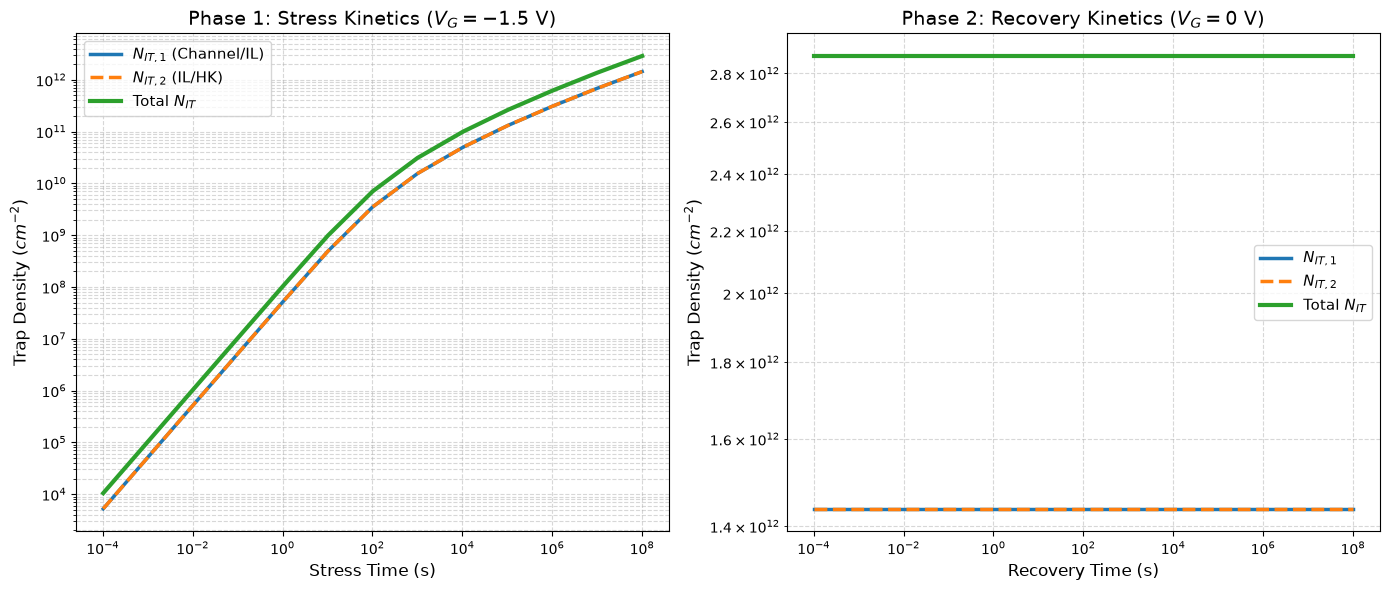

## 4. Initial RD Results Using the Iterative Solver

The initial RD simulations were performed using the updated device parameters: IL thickness of 1 nm, High-k thickness of 1.5 nm, $K_{IL}=4$, and $K_{HK}=20$. Both absorbing and reflective H$_2$ boundary conditions were investigated, with the simulations extended to $10^8$ s to examine the long-time behavior.

With the original four coupling iterations, the calculated $N_{IT,1}$ and $N_{IT,2}$ did not satisfy the expected condition $N_{IT,1} \approx N_{IT,2}$. Increasing the number of iterations brought the two trap densities closer; however, at sufficiently high iteration counts, $N_{IT,2}$ became larger than $N_{IT,1}$. This indicates that the original iterative scheme may not be adequately resolving the coupled RD equations.
<!-- 
For the absorbing boundary condition, the long-time stress behavior showed the local power-law exponent approaching the expected $n=1/6$ regime as the simulation time was extended toward $10^8$ s. The reflective-boundary case was also evaluated to examine the effect of the H$_2$ boundary condition on the long-time kinetics. -->

These results provide an initial numerical assessment of the RD model. The corresponding figures and simulation data are presented above. The remaining discrepancy in the $N_{IT,1}$ and $N_{IT,2}$ sanity check motivates the use of a fully coupled Newton-Raphson formulation in the next section.

## 5. Fully Coupled Newton--Raphson Formulation

The discrepancy between $N_{IT,1}$ and $N_{IT,2}$ obtained with the iterative solver indicates that the coupled RD equations require a more consistent simultaneous solution. The Newton--Raphson method was therefore implemented to solve the complete discretized system at each time step rather than updating the individual quantities through a fixed number of coupling iterations.

The unknown vector at each time step contains the discretized atomic-H concentration in the IL, the molecular-H$_2$ concentration in the High-$k$ layer, and the two interface trap densities:

$$
\mathbf{X} =
\left[
N_H^{(1)},\ldots,N_H^{(N_{IL})},
N_{H_2}^{(1)},\ldots,N_{H_2}^{(N_{HK})},
N_{IT,1},N_{IT,2}
\right]^T .
$$

The spatially discretized RD equations, interface reaction equations, and the H$_2$ boundary condition are written as a nonlinear residual system:

$$
\mathbf{F}(\mathbf{X}) = \mathbf{0}.
$$

At every time step, the Newton--Raphson method updates the solution according to

$$
\mathbf{J}\left(\mathbf{X}^{(k)}\right)
\Delta\mathbf{X}
=
-\mathbf{F}\left(\mathbf{X}^{(k)}\right),
$$

where the Jacobian is

$$
\mathbf{J}
=
\frac{\partial\mathbf{F}}{\partial\mathbf{X}}.
$$

The state vector is then updated as

$$
\mathbf{X}^{(k+1)}
=
\mathbf{X}^{(k)}
+
\Delta\mathbf{X}.
$$

The Jacobian is evaluated numerically using finite differences, and the resulting linear system is solved using Gaussian elimination with partial pivoting. This provides a simultaneous treatment of the atomic-H concentration, molecular-H$_2$ concentration, and interface-trap densities.

The implementation retains the same RD mechanism: atomic H is generated at the Si/IL interface, diffuses through the interlayer, participates in the reaction at the IL/High-$k$ interface, and the resulting molecular H$_2$ diffuses through the High-$k$ layer. The forward reactions are active during stress and are switched off during recovery, while the reverse reactions remain active.

For the present calculation, the device geometry is set to an IL thickness of $1\,\mathrm{nm}$ with $K_{IL}=4$ and a High-$k$ thickness of $1.5\,\mathrm{nm}$ with $K_{HK}=20$. Simulations are performed over the temperature range $65$--$150^\circ\mathrm{C}$, with $V_G=-1.5\,\mathrm{V}$ during stress and $V_G=0\,\mathrm{V}$ during recovery.

The purpose of this formulation is not to introduce a different physical degradation model, but to obtain a more consistent numerical solution of the same coupled RD equations. The resulting trap-density evolution, hydrogen concentrations, convergence behavior, and long-time kinetics are examined in the following section.

## 6. Simulation-1 Configuration

The spatial domain was discretized using 30 nodes in the IL and 200 nodes in the High-$k$ layer. The interface reaction region was represented using $\delta=1.5\times10^{-8}\,\mathrm{cm}$.

Four temperatures were simulated:

$$
T = 65,\ 85,\ 125,\ 150^\circ\mathrm{C}.
$$

The stress condition was applied at

$$
V_G=-1.5\,\mathrm{V},
$$

with a stress duration of $10^4\,\mathrm{s}$ for this computational run. Recovery was subsequently simulated for $10^8\,\mathrm{s}$ at zero gate bias.

The reaction and diffusion parameters were evaluated at each temperature using the Arrhenius form

$$
K(T)=K_0\exp\left(-\frac{E_A}{k_BT}\right),
$$

with the corresponding parameters for $K_{F1}$, $K_{R1}$, $K_{F2}$, $K_{R2}$, $D_H$, and $D_{H_2}$.

For the H$_2$ boundary at the metal-gate side, the absorbing condition was used for the primary simulations:

$$
N_{H_2}(x=L_{HK})=0.
$$

The coupled nonlinear system contains 232 unknowns: 30 atomic-H concentrations, 200 molecular-H$_2$ concentrations, and the two interface trap densities. At each time step, up to 15 Newton iterations were performed, with the Jacobian evaluated numerically using finite differences. The resulting linear system was solved using Gaussian elimination with partial pivoting.

The simulations were performed independently for each temperature using parallel execution. The quantities recorded for analysis were $N_{IT,1}$, $N_{IT,2}$, the atomic-H concentration at the first interface, the molecular-H$_2$ concentration at the second interface, and the integrated H$_2$ concentration remaining in the High-$k$ region.



In [1]:
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <pthread.h> 


#define NX_IL 30                  
#define NX_HK 200                 
#define N_VARS (NX_IL + NX_HK + 2) 
#define DX_IL (1.0e-7 / NX_IL) 
// Values suggested
#define DX_HK (1.5e-7 / NX_HK)
#define DELTA 1.5e-8              
#define HALF_DELTA (DELTA / 2.0)
#define KB 8.617333262e-5

pthread_mutex_t print_mutex = PTHREAD_MUTEX_INITIALIZER;

typedef struct {
    double KF1_STRESS; double KR1_VAL;
    double KF2_VAL; double KR2_VAL;
    double DH_IL; double DH2_HK;
    double N01; double N02;
    double t_stress_total;
} PhysicsParams;

typedef struct {
    int thread_id;
    double T_celsius;
    double E_il_MV;
} ThreadData;

double arrhenius(double prefactor, double Ea, double T) {
    return prefactor * exp(-Ea / (KB * T));
}

// CACHE-OPTIMIZED DENSE SOLVER (Chekc the mathematics)
int solve_dense(int n, double *A, double *b, double *x) {
    for (int i = 0; i < n; i++) x[i] = b[i];
    for (int i = 0; i < n; i++) {
        int max_row = i;
        double max_val = fabs(A[i*n + i]);
        for (int k = i + 1; k < n; k++) {
            if (fabs(A[k*n + i]) > max_val) {
                max_val = fabs(A[k*n + i]);
                max_row = k;
            }
        }
        if (max_val < 1e-20) return 0; 
        
        if (max_row != i) {
            double *Ai = A + i*n;
            double *Amax = A + max_row*n;
            for (int j = i; j < n; j++) {
                double tmp = Ai[j]; 
                Ai[j] = Amax[j]; 
                Amax[j] = tmp;
            }
            double tmp = x[i]; x[i] = x[max_row]; x[max_row] = tmp;
        }
        
        double *Ai = A + i*n;
        for (int k = i + 1; k < n; k++) {
            double *Ak = A + k*n;
            double factor = Ak[i] / Ai[i];
            
            for (int j = i; j < n; j++) Ak[j] -= factor * Ai[j];
            x[k] -= factor * x[i];
        }
    }
    
    for (int i = n - 1; i >= 0; i--) {
        double sum = 0.0;
        double *Ai = A + i*n;
        for (int j = i + 1; j < n; j++) sum += Ai[j] * x[j];
        x[i] = (x[i] - sum) / Ai[i];
    }
    return 1;
}

void compute_residuals(double *X, double *F, double *X_prev, double dt, double t, int is_recovery, PhysicsParams *p) {
    double *H = X;
    double *H2 = &X[NX_IL];
    double Nit1 = X[N_VARS - 2];
    double Nit2 = X[N_VARS - 1];

    // Both forward reactions shut off during recovery
    double KF1 = is_recovery ? 0.0 : p->KF1_STRESS;
    double KF2 = is_recovery ? 0.0 : p->KF2_VAL;
    
    double dNit1_dt = KF1 * (p->N01 - Nit1) - p->KR1_VAL * Nit1 * H[0];
    double dNit2_dt = KF2 * (p->N02 - Nit2) * H[NX_IL-1] - p->KR2_VAL * Nit2 * H2[0];

    F[N_VARS - 2] = (Nit1 - X_prev[N_VARS - 2]) / dt - dNit1_dt;
    F[N_VARS - 1] = (Nit2 - X_prev[N_VARS - 1]) / dt - dNit2_dt;

    double DH2_eff = is_recovery ? p->DH2_HK / (1.0 + 7.0 * (t / p->t_stress_total)) : p->DH2_HK;

    // Interface 1 (Silicon/IL) Boundary Condition
    F[0] = (H[0] - X_prev[0]) / dt - (p->DH_IL * (H[1] - H[0]) / DX_IL) / HALF_DELTA - dNit1_dt / HALF_DELTA;
    
    for(int i=1; i<NX_IL-1; i++) {
        F[i] = (H[i] - X_prev[i]) / dt - p->DH_IL * (H[i+1] - 2*H[i] + H[i-1]) / (DX_IL*DX_IL);
    }
    
    F[NX_IL-1] = (H[NX_IL-1] - X_prev[NX_IL-1]) / dt + (p->DH_IL * (H[NX_IL-1] - H[NX_IL-2]) / DX_IL + dNit2_dt) / HALF_DELTA;

    // Interface 2 (IL/High-K) Boundary Condition
    F[NX_IL] = (H2[0] - X_prev[NX_IL]) / dt - (DH2_eff * (H2[1] - H2[0]) / DX_HK + dNit2_dt) / HALF_DELTA;
    
    for(int i=1; i<NX_HK-1; i++) {
        F[NX_IL + i] = (H2[i] - X_prev[NX_IL + i]) / dt - DH2_eff * (H2[i+1] - 2*H2[i] + H2[i-1]) / (DX_HK*DX_HK);
    }
    
    // METAL GATE BOUNDARY CONDITION TOGGLE Between these two (Ask them what is happening there at metal gate)

    // Absorbing Sink (Vents H2 out. Required to prevent instant choking at 1.5nm thickness)
    // F[NX_IL + NX_HK - 1] = H2[NX_HK-1] - 0.0;

    //Reflective Wall (Traps H2. Only use this if you increase DX_HK to 1.5 microns)
    F[NX_IL + NX_HK - 1] = (H2[NX_HK-1] - X_prev[NX_IL + NX_HK - 1]) / dt - DH2_eff * (2.0 * H2[NX_HK-2] - 2.0 * H2[NX_HK-1]) / (DX_HK * DX_HK);
}

void compute_jacobian(double *X, double *F_base, double *J, double *X_prev, double dt, double t, int is_recovery, PhysicsParams *p, double *F_temp) {
    for (int j = 0; j < N_VARS; j++) {
        double epsilon = 1e-6 * fabs(X[j]) + 1.0; 
        X[j] += epsilon;
        
        compute_residuals(X, F_temp, X_prev, dt, t, is_recovery, p);
        
        for (int i = 0; i < N_VARS; i++) {
            J[i * N_VARS + j] = (F_temp[i] - F_base[i]) / epsilon;
        }
        X[j] -= epsilon; 
    }
}


// It takes some time compared to previous one so parallel computing is implimented
// THREAD PAYLOAD
void* run_simulation_thread(void* arg) {
    ThreadData* data = (ThreadData*)arg;
    double T_celsius = data->T_celsius;
    double T_kelvin = T_celsius + 273.15;
    
    pthread_mutex_lock(&print_mutex);
    printf("Thread %d starting simulation for %.0f C...\n", data->thread_id, T_celsius);
    pthread_mutex_unlock(&print_mutex);

    PhysicsParams p;
    p.N01 = 5.0e12;
    p.N02 = 5.0e13;
    // STRESS TIME: Set to 10^8 seconds
    p.t_stress_total = 1.0e4;
    
    p.KF1_STRESS = arrhenius(0.22, 0.40, T_kelvin) * exp(data->E_il_MV * (0.38 + 1.2 * 0.01 / (KB * T_kelvin)));
    p.KR1_VAL = arrhenius(5.0e-6, 0.12, T_kelvin);
    p.KF2_VAL = arrhenius(5.75e3, 0.235, T_kelvin);
    p.KR2_VAL = arrhenius(7.5e-4, 0.20, T_kelvin);
    p.DH_IL = arrhenius(2.0e-2, 0.20, T_kelvin);
    p.DH2_HK = arrhenius(9.5e-8, 0.50, T_kelvin);

    double *X = (double*)calloc(N_VARS, sizeof(double));
    double *X_prev = (double*)calloc(N_VARS, sizeof(double));
    double *F = (double*)calloc(N_VARS, sizeof(double));
    double *J = (double*)calloc(N_VARS * N_VARS, sizeof(double));
    double *deltaX = (double*)calloc(N_VARS, sizeof(double));
    double *F_temp = (double*)calloc(N_VARS, sizeof(double));

    double *H = X;
    double *H2 = &X[NX_IL];

    double t = 0.0, dt = 1.0e-9;
    double t_recov = 1.0e4;
    
    char filename[256];
    sprintf(filename, "nr_results_%.0fC.csv", T_celsius);
    FILE *fp = fopen(filename, "w");
    
    if (fp != NULL) {
        fprintf(fp, "Phase,Time,Nit1,Nit2,Atomic_H0,Mol_H2,H2_Remaining,H2_Lost\n");

        for (int phase = 0; phase < 2; phase++) {
            int is_recovery = phase;
            t = 0.0; dt = 1.0e-9;
            double t_max = is_recovery ? t_recov : p.t_stress_total;
            
            while (t < t_max) {
                if (t + dt > t_max) dt = t_max - t;

                for (int i = 0; i < N_VARS; i++) X_prev[i] = X[i];

                for (int iter = 0; iter < 15; iter++) { 
                    compute_residuals(X, F, X_prev, dt, t, is_recovery, &p);
                    double max_res = 0.0;
                    for (int i=0; i<N_VARS; i++) if (fabs(F[i]) > max_res) max_res = fabs(F[i]);
                    if (max_res < 1e-4) break; 

                    compute_jacobian(X, F, J, X_prev, dt, t, is_recovery, &p, F_temp);
                    for (int i=0; i<N_VARS; i++) F[i] = -F[i];
                    if (!solve_dense(N_VARS, J, F, deltaX)) break; 

                    for (int i=0; i<N_VARS; i++) {
                        X[i] += deltaX[i];
                        if (X[i] < 0.0) X[i] = 0.0; 
                    }
                }
                t += dt;
                
                double H2_remaining = 0.0;
                for (int i = 0; i < NX_HK; i++) {
                    H2_remaining += H2[i] * DX_HK;
                }
                double Nit2_current = X[N_VARS-1];
                double H2_lost = Nit2_current - H2_remaining;
                
                fprintf(fp, "%s,%e,%.8e,%.8e,%.8e,%.8e,%.8e,%.8e\n", 
                        is_recovery ? "Recovery" : "Stress", t, X[N_VARS-2], Nit2_current, H[0], H2[0], H2_remaining, H2_lost);
                
                // this is important for long time duration
                dt *= 1.05;
                if (dt > 1.0e5) dt = 1.0e5;
            }
        }
        fclose(fp);
    }
    
    free(X); free(X_prev); free(F); free(J); free(deltaX); free(F_temp);
    
    pthread_mutex_lock(&print_mutex);
    printf("Thread %d finished %.0f C. Saved to %s\n", data->thread_id, T_celsius, filename);
    pthread_mutex_unlock(&print_mutex);
    
    pthread_exit(NULL);
    return NULL;
}


// MASTER RUN FUNCTION

void run_parallel_sweep() {
    double temperatures_C[] = {65.0, 85.0, 125.0, 150.0};
    int num_temps = 4;

    //This portion is additional sugetion check it later
    // NBTI Electrostatics for an HKMG p-MOSFET
    double VG = -1.5; 
    
    // metal gate flatband voltage and strong inversion surface potential
    double V_fb = -0.1; 
    double psi_s = -0.8;                   
    
    // Calculate absolute voltage drop across the oxide
    double V_ox = fabs(VG - V_fb - psi_s);    
    
    // Calculate field magnitude (Yields 4.615 MV/cm)
    double E_il_MV = (V_ox / (1.0e-7 + 1.5e-7 * (4.0 / 20.0))) / 1.0e6;      

    printf("Booting parallel simulations...\n");

    pthread_t threads[4];
    ThreadData thread_data[4];

    for (int i = 0; i < num_temps; i++) {
        thread_data[i].thread_id = i;
        thread_data[i].T_celsius = temperatures_C[i];
        thread_data[i].E_il_MV = E_il_MV;
        
        pthread_create(&threads[i], NULL, run_simulation_thread, (void*)&thread_data[i]);
    }

    for (int i = 0; i < num_temps; i++) {
        pthread_join(threads[i], NULL);
    }
    
    printf("All parallel simulations completed successfully!\n");
}
run_parallel_sweep();


Booting parallel simulations...
Thread 0 starting simulation for 65 C...
Thread 2 starting simulation for 125 C...
Thread 1 starting simulation for 85 C...
Thread 3 starting simulation for 150 C...
Thread 3 finished 150 C. Saved to nr_results_150C.csv
Thread 0 finished 65 C. Saved to nr_results_65C.csv
Thread 2 finished 125 C. Saved to nr_results_125C.csv
Thread 1 finished 85 C. Saved to nr_results_85C.csv
All parallel simulations completed successfully!


ERROR: received bad message: No such comm registered: 64eca993-00b2-4c06-8ead-f347eee86292
Message type: comm_msg


The resulting stress and recovery kinetics for the individual temperatures are presented in the following figures.

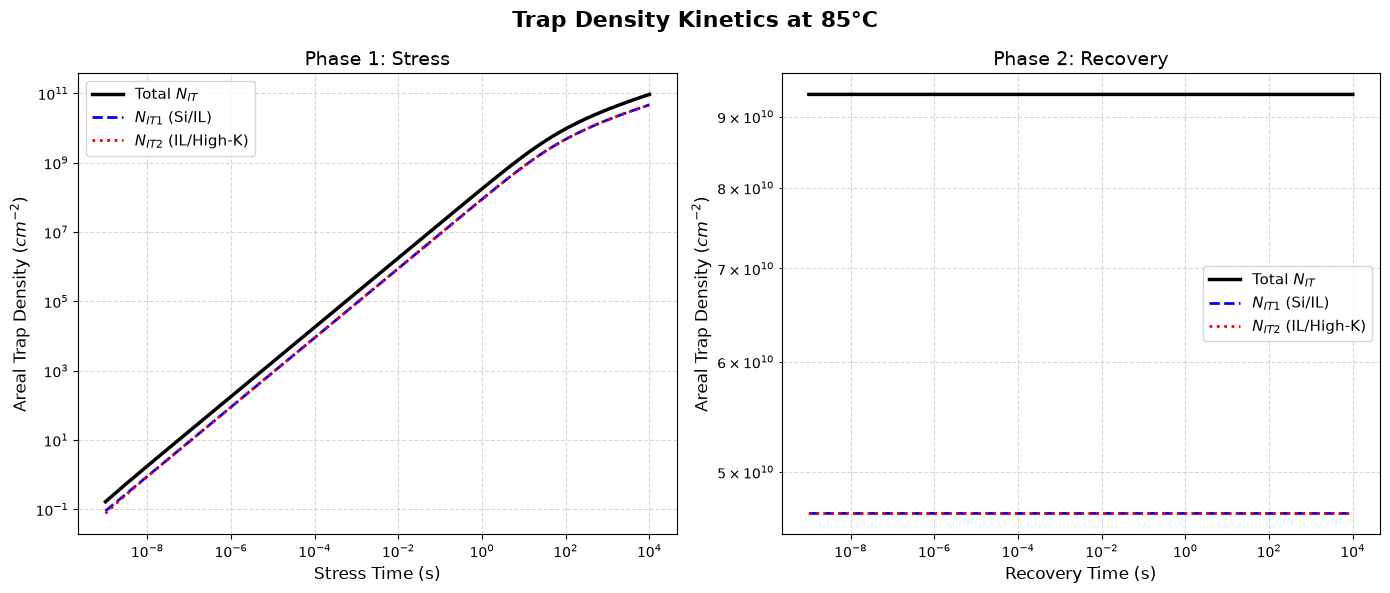

For all temperatures (Just to show the Nt1 and Nt2 line i have shown a plot above, for other temperatures- plots look similar. Below a plot combining all)
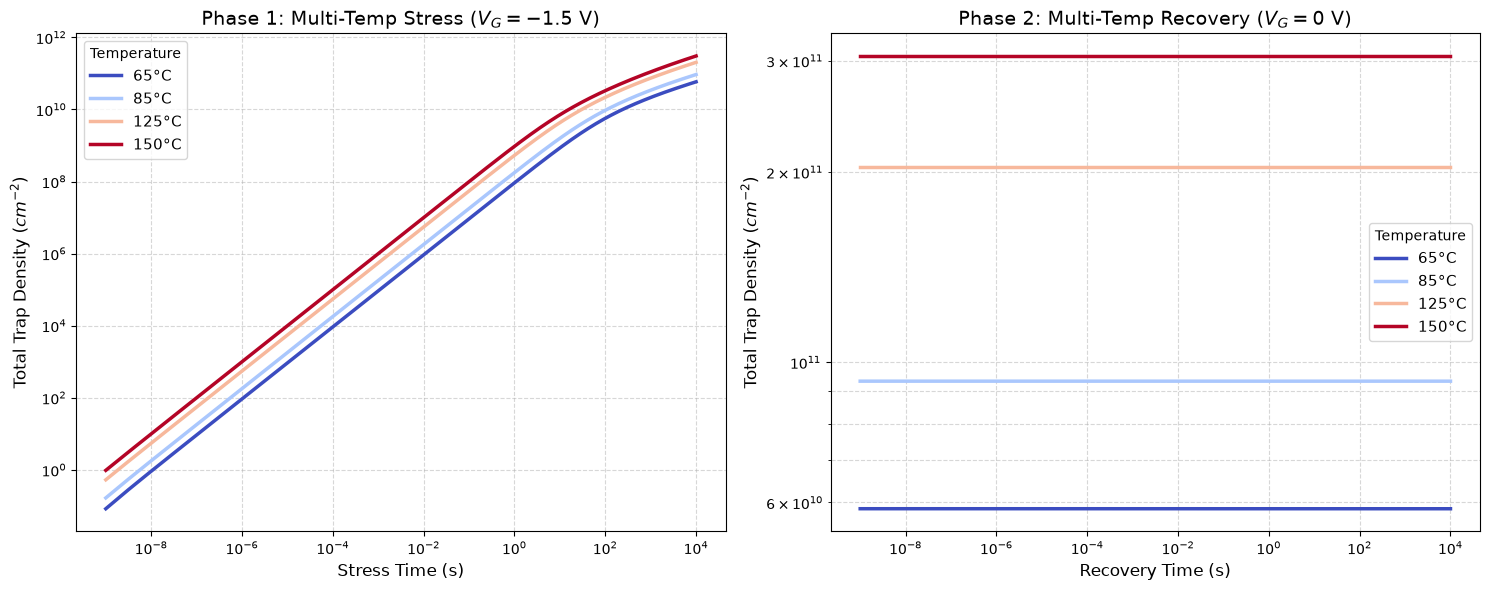

### 7.1 Stress Power-Law Behavior

The local stress-time exponent was calculated from

$$
n(t)=\frac{d\log N_{IT}}{d\log t}.
$$

The results show an initial exponent close to unity, followed by a gradual decrease at longer stress times. At the end of the present $10^4\,\mathrm{s}$ simulation, the exponent remains above the expected long-time RD value of
(is it correct interpretation?)
$$
n=\frac{1}{6}. 🤔 
$$

Therefore, the $10^4\,\mathrm{s}$ simulation does not yet demonstrate convergence to the asymptotic $1/6$ regime. 
The temperature dependence is also evident: the decrease in the local exponent occurs at progressively different characteristic times as temperature is varied. A longer stress simulation (below) will therefore be required to check.
The below plot is for the above config. (and the plots and the power law thing has been done by AI. so attentions are required)
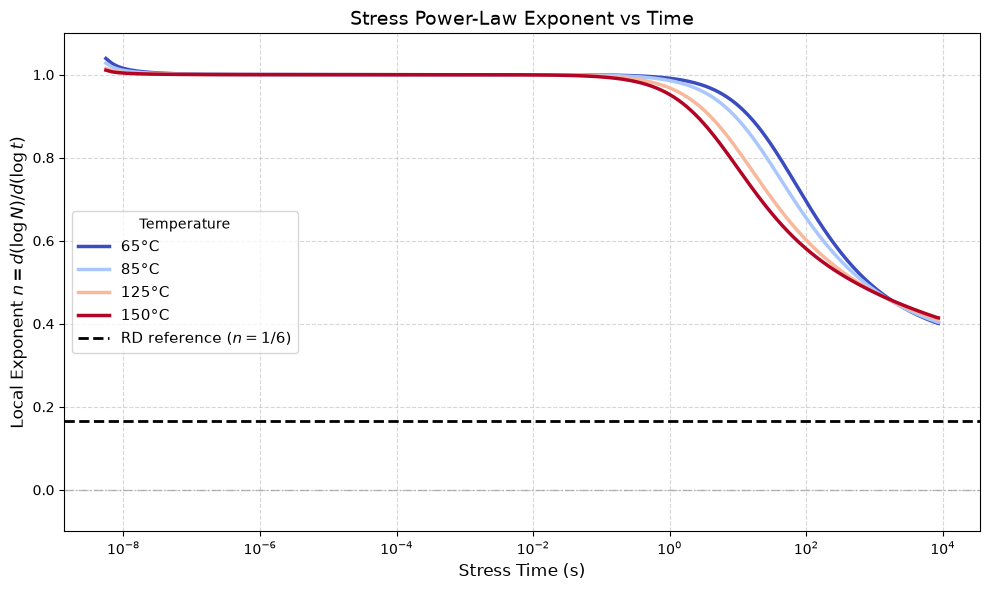


SOme Portions of Data  generated. (I didnt integarte this version to webpage, it takes some time, i will optimize that if required)
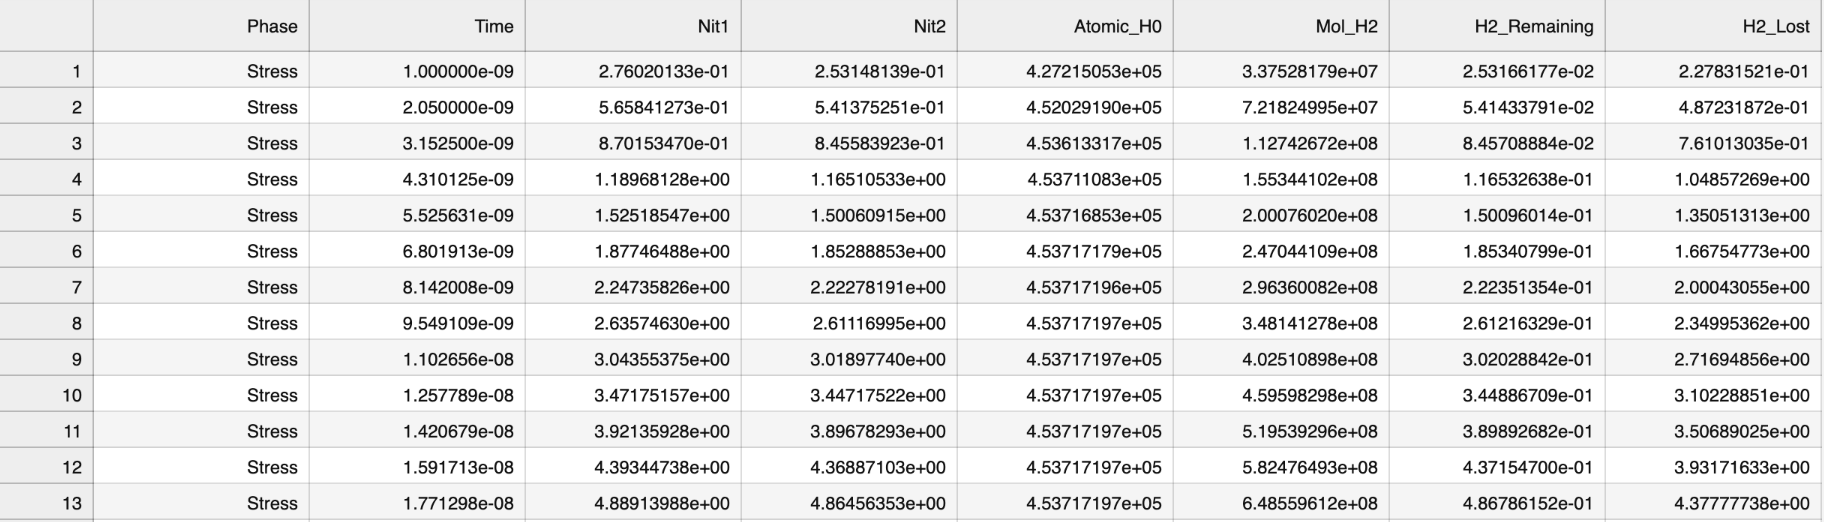
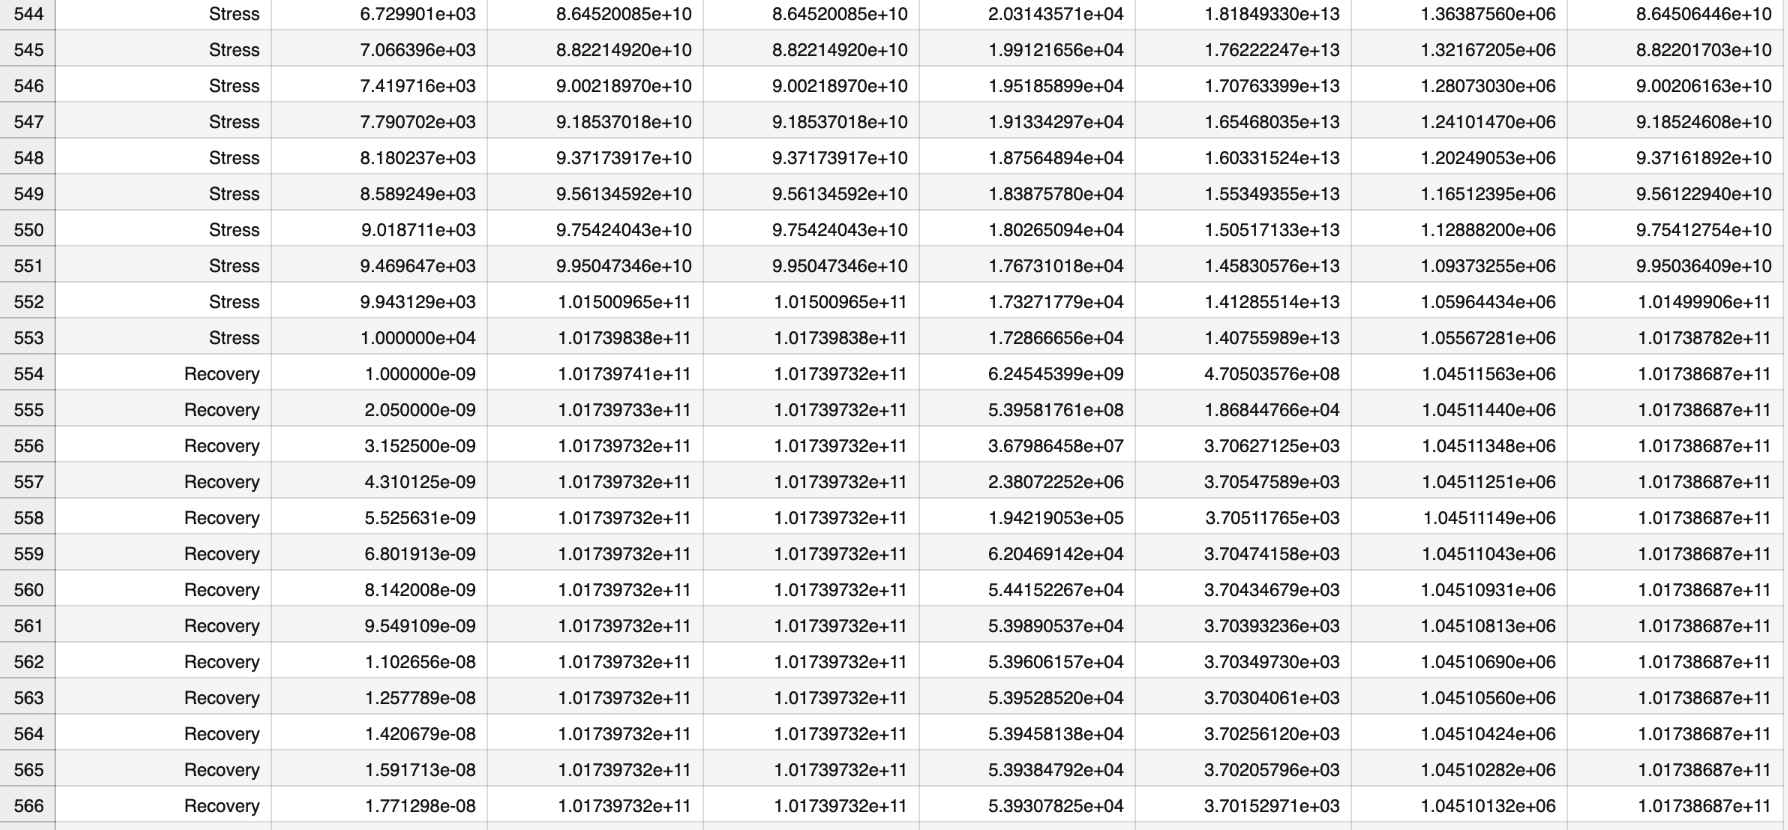

### Long-Time Simulation Results (The figures below show the results obtained from the long-time simulation.)
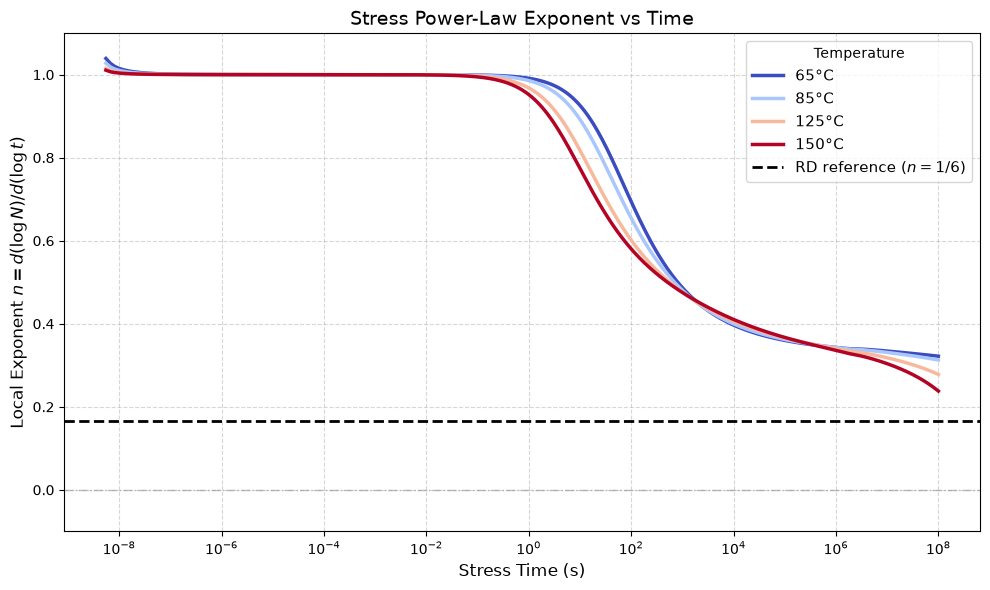
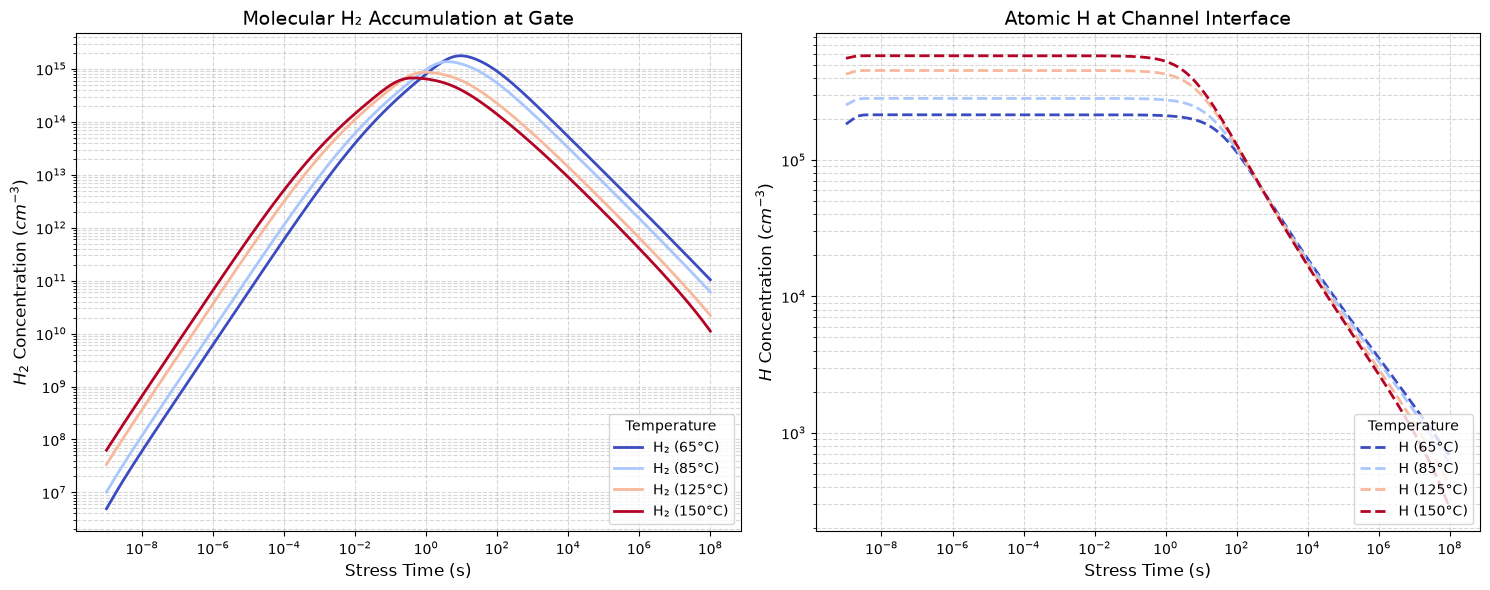
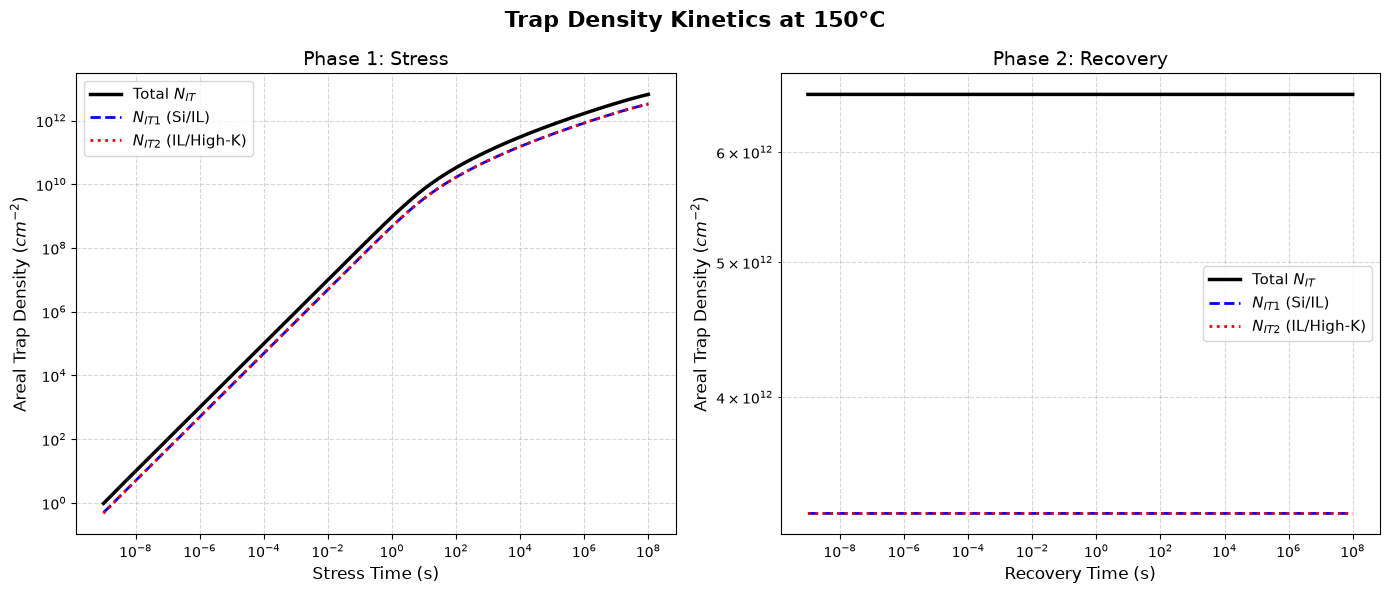

## Reflective H$_2$ Boundary Condition — Same Configuration
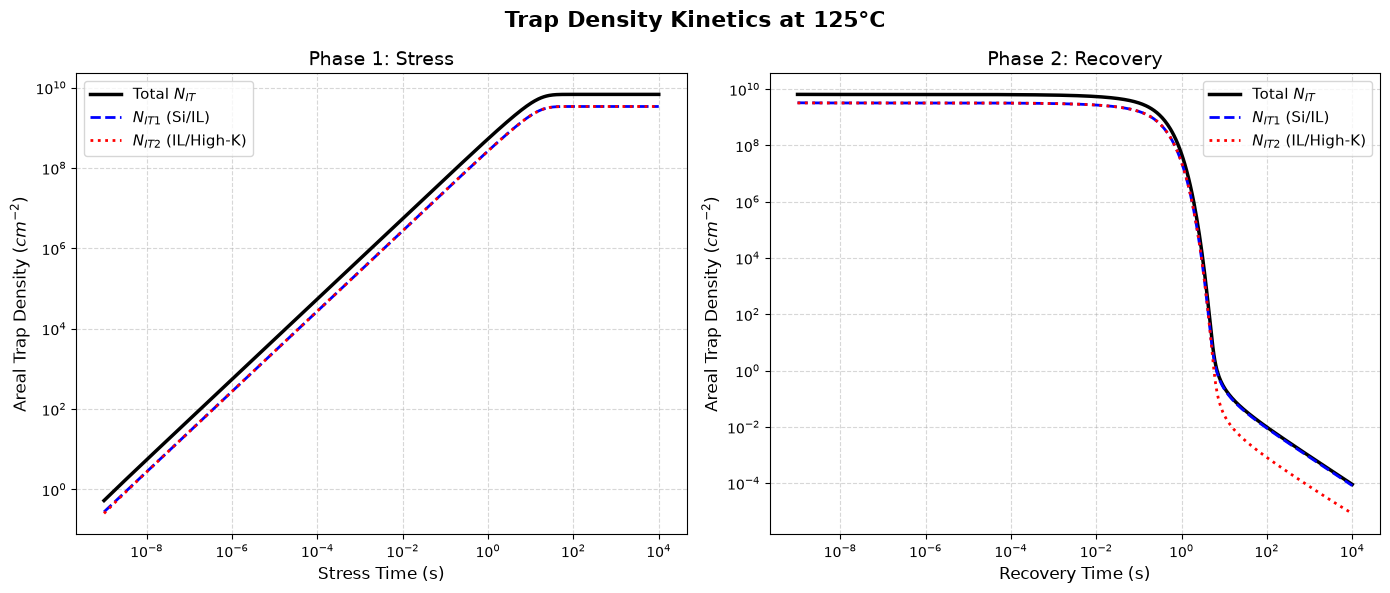
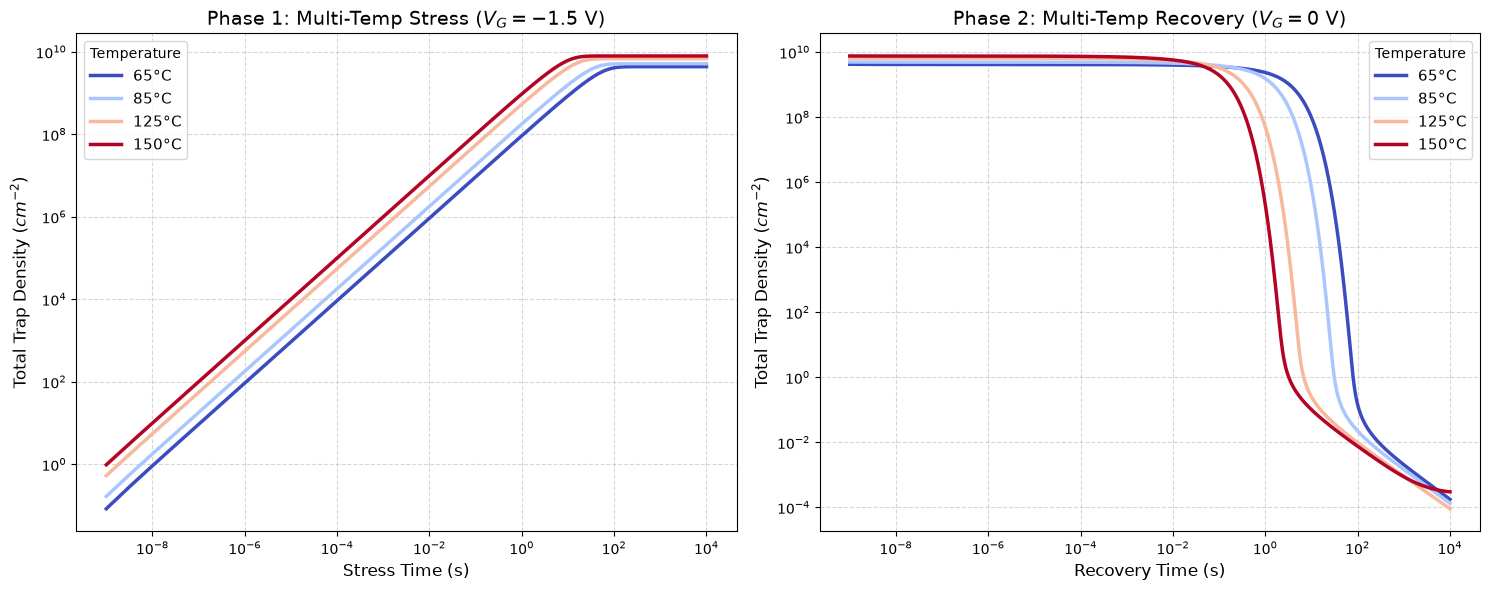
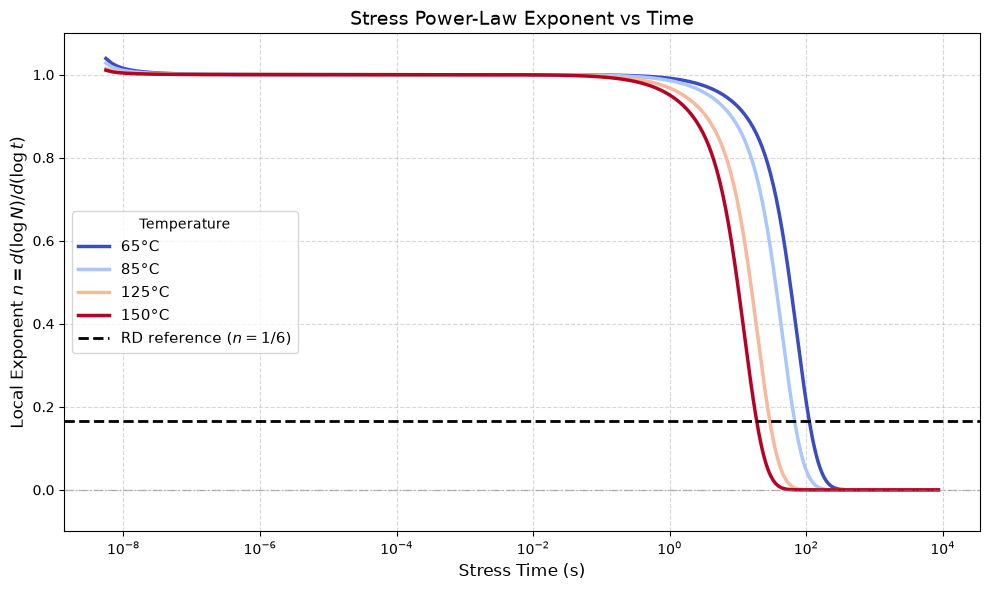
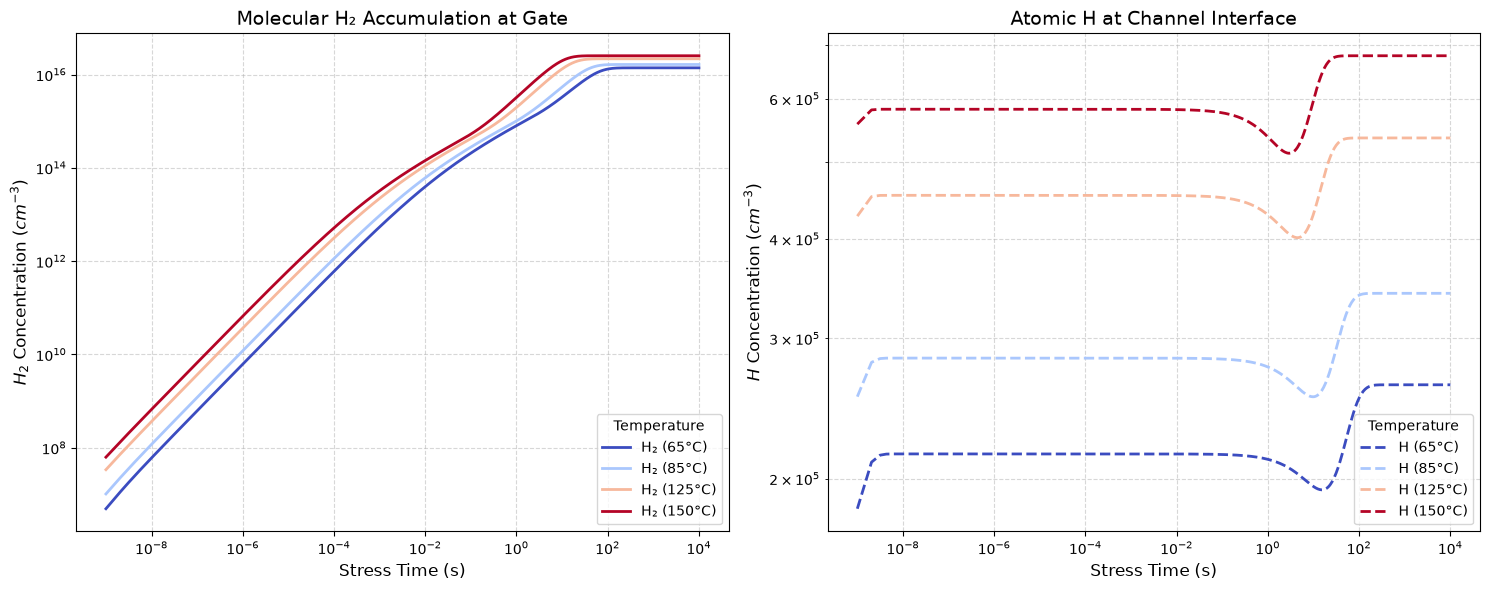

## 5. Voltage-Dependent RD Analysis

In [1]:
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <pthread.h> 

#define NX_IL 30                  
#define NX_HK 200   //Should also check the effect this number             
#define N_VARS (NX_IL + NX_HK + 2) 
#define DX_IL (1.0e-7 / NX_IL) 
// Values suggested
#define DX_HK (1.5e-7 / NX_HK)
#define DELTA 1.5e-8              
#define HALF_DELTA (DELTA / 2.0)
#define KB 8.617333262e-5

pthread_mutex_t print_mutex = PTHREAD_MUTEX_INITIALIZER;

typedef struct {
    double KF1_STRESS; double KR1_VAL;
    double KF2_VAL; double KR2_VAL;
    double DH_IL; double DH2_HK;
    double N01; double N02;
    double t_stress_total;
} PhysicsParams;

typedef struct {
    int thread_id;
    double T_celsius;
    double E_il_MV;
    double VG; // Added to pass voltage to the thread for filenames
} ThreadData;

double arrhenius(double prefactor, double Ea, double T) {
    return prefactor * exp(-Ea / (KB * T));
}

// CACHE-OPTIMIZED DENSE SOLVER (Chekc the mathematics)
int solve_dense(int n, double *A, double *b, double *x) {
    for (int i = 0; i < n; i++) x[i] = b[i];
    
    for (int i = 0; i < n; i++) {
        int max_row = i;
        double max_val = fabs(A[i*n + i]);
        
        for (int k = i + 1; k < n; k++) {
            if (fabs(A[k*n + i]) > max_val) {
                max_val = fabs(A[k*n + i]);
                max_row = k;
            }
        }
        if (max_val < 1e-20) return 0; 
        
        if (max_row != i) {
            double *Ai = A + i*n;
            double *Amax = A + max_row*n;
            for (int j = i; j < n; j++) {
                double tmp = Ai[j]; 
                Ai[j] = Amax[j]; 
                Amax[j] = tmp;
            }
            double tmp = x[i]; x[i] = x[max_row]; x[max_row] = tmp;
        }
        
        double *Ai = A + i*n;
        for (int k = i + 1; k < n; k++) {
            double *Ak = A + k*n;
            double factor = Ak[i] / Ai[i];
            
            for (int j = i; j < n; j++) Ak[j] -= factor * Ai[j];
            x[k] -= factor * x[i];
        }
    }
    
    for (int i = n - 1; i >= 0; i--) {
        double sum = 0.0;
        double *Ai = A + i*n;
        for (int j = i + 1; j < n; j++) sum += Ai[j] * x[j];
        x[i] = (x[i] - sum) / Ai[i];
    }
    return 1;
}

void compute_residuals(double *X, double *F, double *X_prev, double dt, double t, int is_recovery, PhysicsParams *p) {
    double *H = X;
    double *H2 = &X[NX_IL];
    double Nit1 = X[N_VARS - 2];
    double Nit2 = X[N_VARS - 1];

    // Both forward reactions shut off during recovery
    double KF1 = is_recovery ? 0.0 : p->KF1_STRESS;
    double KF2 = is_recovery ? 0.0 : p->KF2_VAL;
    
    double dNit1_dt = KF1 * (p->N01 - Nit1) - p->KR1_VAL * Nit1 * H[0];
    double dNit2_dt = KF2 * (p->N02 - Nit2) * H[NX_IL-1] - p->KR2_VAL * Nit2 * H2[0];

    F[N_VARS - 2] = (Nit1 - X_prev[N_VARS - 2]) / dt - dNit1_dt;
    F[N_VARS - 1] = (Nit2 - X_prev[N_VARS - 1]) / dt - dNit2_dt;

    double DH2_eff = is_recovery ? p->DH2_HK / (1.0 + 7.0 * (t / p->t_stress_total)) : p->DH2_HK;

    // Interface 1 (Silicon/IL) Boundary Condition
    F[0] = (H[0] - X_prev[0]) / dt - (p->DH_IL * (H[1] - H[0]) / DX_IL) / HALF_DELTA - dNit1_dt / HALF_DELTA;
    
    for(int i=1; i<NX_IL-1; i++) {
        F[i] = (H[i] - X_prev[i]) / dt - p->DH_IL * (H[i+1] - 2*H[i] + H[i-1]) / (DX_IL*DX_IL);
    }
    
    F[NX_IL-1] = (H[NX_IL-1] - X_prev[NX_IL-1]) / dt + (p->DH_IL * (H[NX_IL-1] - H[NX_IL-2]) / DX_IL + dNit2_dt) / HALF_DELTA;

    // Interface 2 (IL/High-K) Boundary Condition
    F[NX_IL] = (H2[0] - X_prev[NX_IL]) / dt - (DH2_eff * (H2[1] - H2[0]) / DX_HK + dNit2_dt) / HALF_DELTA;
    
    for(int i=1; i<NX_HK-1; i++) {
        F[NX_IL + i] = (H2[i] - X_prev[NX_IL + i]) / dt - DH2_eff * (H2[i+1] - 2*H2[i] + H2[i-1]) / (DX_HK*DX_HK);
    }
    
    // METAL GATE BOUNDARY CONDITION TOGGLE Between these two (Ask them what is happening there at metal gate)

    // Absorbing Sink (Vents H2 out. Required to prevent instant choking at 1.5nm thickness)
    // F[NX_IL + NX_HK - 1] = H2[NX_HK-1] - 0.0;

    //Reflective Wall (Traps H2. Only use this if you increase DX_HK to 1.5 microns)
    F[NX_IL + NX_HK - 1] = (H2[NX_HK-1] - X_prev[NX_IL + NX_HK - 1]) / dt - DH2_eff * (2.0 * H2[NX_HK-2] - 2.0 * H2[NX_HK-1]) / (DX_HK * DX_HK);
}

void compute_jacobian(double *X, double *F_base, double *J, double *X_prev, double dt, double t, int is_recovery, PhysicsParams *p, double *F_temp) {
    for (int j = 0; j < N_VARS; j++) {
        double epsilon = 1e-6 * fabs(X[j]) + 1.0; 
        X[j] += epsilon;
        
        compute_residuals(X, F_temp, X_prev, dt, t, is_recovery, p);
        
        for (int i = 0; i < N_VARS; i++) {
            J[i * N_VARS + j] = (F_temp[i] - F_base[i]) / epsilon;
        }
        X[j] -= epsilon; 
    }
}


// It takes some time compared to previous one so parallel computing is implimented
// THREAD PAYLOAD
void* run_simulation_thread(void* arg) {
    ThreadData* data = (ThreadData*)arg;
    double T_celsius = data->T_celsius;
    double VG = data->VG;
    double T_kelvin = T_celsius + 273.15;
    
    pthread_mutex_lock(&print_mutex);
    printf("Thread %d starting simulation for VG = %.1f V at %.0f C...\n", data->thread_id, VG, T_celsius);
    pthread_mutex_unlock(&print_mutex);

    PhysicsParams p;
    p.N01 = 5.0e12;
    p.N02 = 5.0e13;
    // STRESS TIME: Set to 10^8 seconds
    p.t_stress_total = 1.0e4;
    
    p.KF1_STRESS = arrhenius(0.22, 0.40, T_kelvin) * exp(data->E_il_MV * (0.38 + 1.2 * 0.01 / (KB * T_kelvin)));
    p.KR1_VAL = arrhenius(5.0e-6, 0.12, T_kelvin);
    p.KF2_VAL = arrhenius(5.75e3, 0.235, T_kelvin);
    p.KR2_VAL = arrhenius(7.5e-4, 0.20, T_kelvin);
    p.DH_IL = arrhenius(2.0e-2, 0.20, T_kelvin);
    p.DH2_HK = arrhenius(9.5e-8, 0.50, T_kelvin);

    double *X = (double*)calloc(N_VARS, sizeof(double));
    double *X_prev = (double*)calloc(N_VARS, sizeof(double));
    double *F = (double*)calloc(N_VARS, sizeof(double));
    double *J = (double*)calloc(N_VARS * N_VARS, sizeof(double));
    double *deltaX = (double*)calloc(N_VARS, sizeof(double));
    double *F_temp = (double*)calloc(N_VARS, sizeof(double));

    double *H = X;
    double *H2 = &X[NX_IL];

    double t = 0.0, dt = 1.0e-9;
    double t_recov = 1.0e4;
    
    char filename[256];
    // Changed filename to reflect voltage instead of temperature
    sprintf(filename, "nr_results_%.1fV.csv", fabs(VG));
    FILE *fp = fopen(filename, "w");
    
    if (fp != NULL) {
        fprintf(fp, "Phase,Time,Nit1,Nit2,Atomic_H0,Mol_H2,H2_Remaining,H2_Lost\n");

        for (int phase = 0; phase < 2; phase++) {
            int is_recovery = phase;
            t = 0.0; dt = 1.0e-9;
            double t_max = is_recovery ? t_recov : p.t_stress_total;
            
            while (t < t_max) {
                if (t + dt > t_max) dt = t_max - t;

                for (int i = 0; i < N_VARS; i++) X_prev[i] = X[i];

                for (int iter = 0; iter < 15; iter++) { 
                    compute_residuals(X, F, X_prev, dt, t, is_recovery, &p);
                    double max_res = 0.0;
                    for (int i=0; i<N_VARS; i++) if (fabs(F[i]) > max_res) max_res = fabs(F[i]);
                    if (max_res < 1e-4) break; 

                    compute_jacobian(X, F, J, X_prev, dt, t, is_recovery, &p, F_temp);
                    for (int i=0; i<N_VARS; i++) F[i] = -F[i];
                    if (!solve_dense(N_VARS, J, F, deltaX)) break; 

                    for (int i=0; i<N_VARS; i++) {
                        X[i] += deltaX[i];
                        if (X[i] < 0.0) X[i] = 0.0; 
                    }
                }
                t += dt;
                
                double H2_remaining = 0.0;
                for (int i = 0; i < NX_HK; i++) {
                    H2_remaining += H2[i] * DX_HK;
                }
                double Nit2_current = X[N_VARS-1];
                double H2_lost = Nit2_current - H2_remaining;
                
                fprintf(fp, "%s,%e,%.8e,%.8e,%.8e,%.8e,%.8e,%.8e\n", 
                        is_recovery ? "Recovery" : "Stress", t, X[N_VARS-2], Nit2_current, H[0], H2[0], H2_remaining, H2_lost);
                
                // this is important for long time duration
                dt *= 1.05;
                if (dt > 1.0e5) dt = 1.0e5;
            }
        }
        fclose(fp);
    }
    
    free(X); free(X_prev); free(F); free(J); free(deltaX); free(F_temp);
    
    pthread_mutex_lock(&print_mutex);
    printf("Thread %d finished VG = %.1f V. Saved to %s\n", data->thread_id, VG, filename);
    pthread_mutex_unlock(&print_mutex);
    
    pthread_exit(NULL);
    return NULL;
}


// MASTER RUN FUNCTION

void run_parallel_sweep() {
    // Replaced temperatures with voltages for the sweep
    double voltages_V[] = {-1.2, -1.5, -1.8, -2.0};
    double fixed_temp_C = 125.0;
    int num_sims = 4;

    // metal gate flatband voltage and strong inversion surface potential
    double V_fb = -0.1; 
    double psi_s = -0.8;                   

    printf("Booting parallel simulations for Voltage Sweep at %.0f C...\n", fixed_temp_C);

    pthread_t threads[4];
    ThreadData thread_data[4];

    for (int i = 0; i < num_sims; i++) {
        double VG = voltages_V[i];
        
        // Calculate absolute voltage drop across the oxide dynamically for each VG
        double V_ox = fabs(VG - V_fb - psi_s);    
        
        // Calculate field magnitude based on current VG
        double E_il_MV = (V_ox / (1.0e-7 + 1.5e-7 * (4.0 / 20.0))) / 1.0e6;      

        thread_data[i].thread_id = i;
        thread_data[i].T_celsius = fixed_temp_C;
        thread_data[i].E_il_MV = E_il_MV;
        thread_data[i].VG = VG;
        
        pthread_create(&threads[i], NULL, run_simulation_thread, (void*)&thread_data[i]);
    }

    for (int i = 0; i < num_sims; i++) {
        pthread_join(threads[i], NULL);
    }
    
    printf("All parallel simulations completed successfully!\n");
}


run_parallel_sweep();


Booting parallel simulations for Voltage Sweep at 125 C...
Thread 0 starting simulation for VG = -1.2 V at 125 C...
Thread 2 starting simulation for VG = -1.8 V at 125 C...
Thread 1 starting simulation for VG = -1.5 V at 125 C...
Thread 3 starting simulation for VG = -2.0 V at 125 C...
Thread 3 finished VG = -2.0 V. Saved to nr_results_2.0V.csv
Thread 0 finished VG = -1.2 V. Saved to nr_results_1.2V.csv
Thread 2 finished VG = -1.8 V. Saved to nr_results_1.8V.csv
Thread 1 finished VG = -1.5 V. Saved to nr_results_1.5V.csv
All parallel simulations completed successfully!


ERROR: received bad message: No such comm registered: 6c0597e9-95d0-427e-9cd4-06ba460e01b2
Message type: comm_msg


## Some portions of data
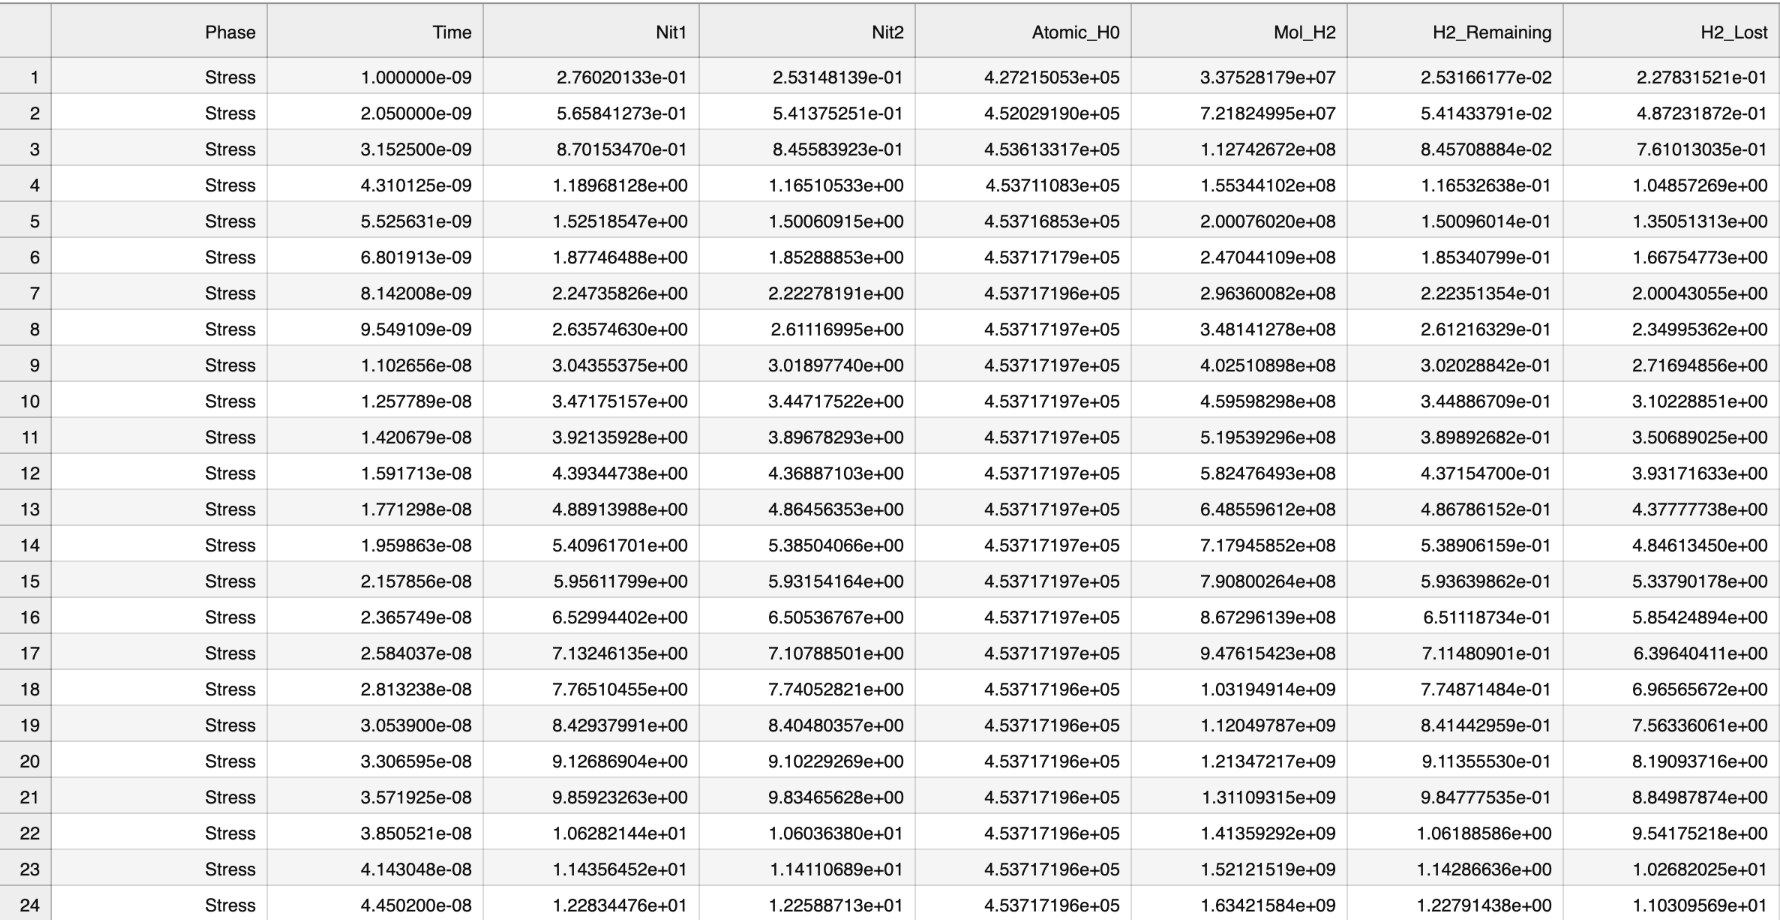
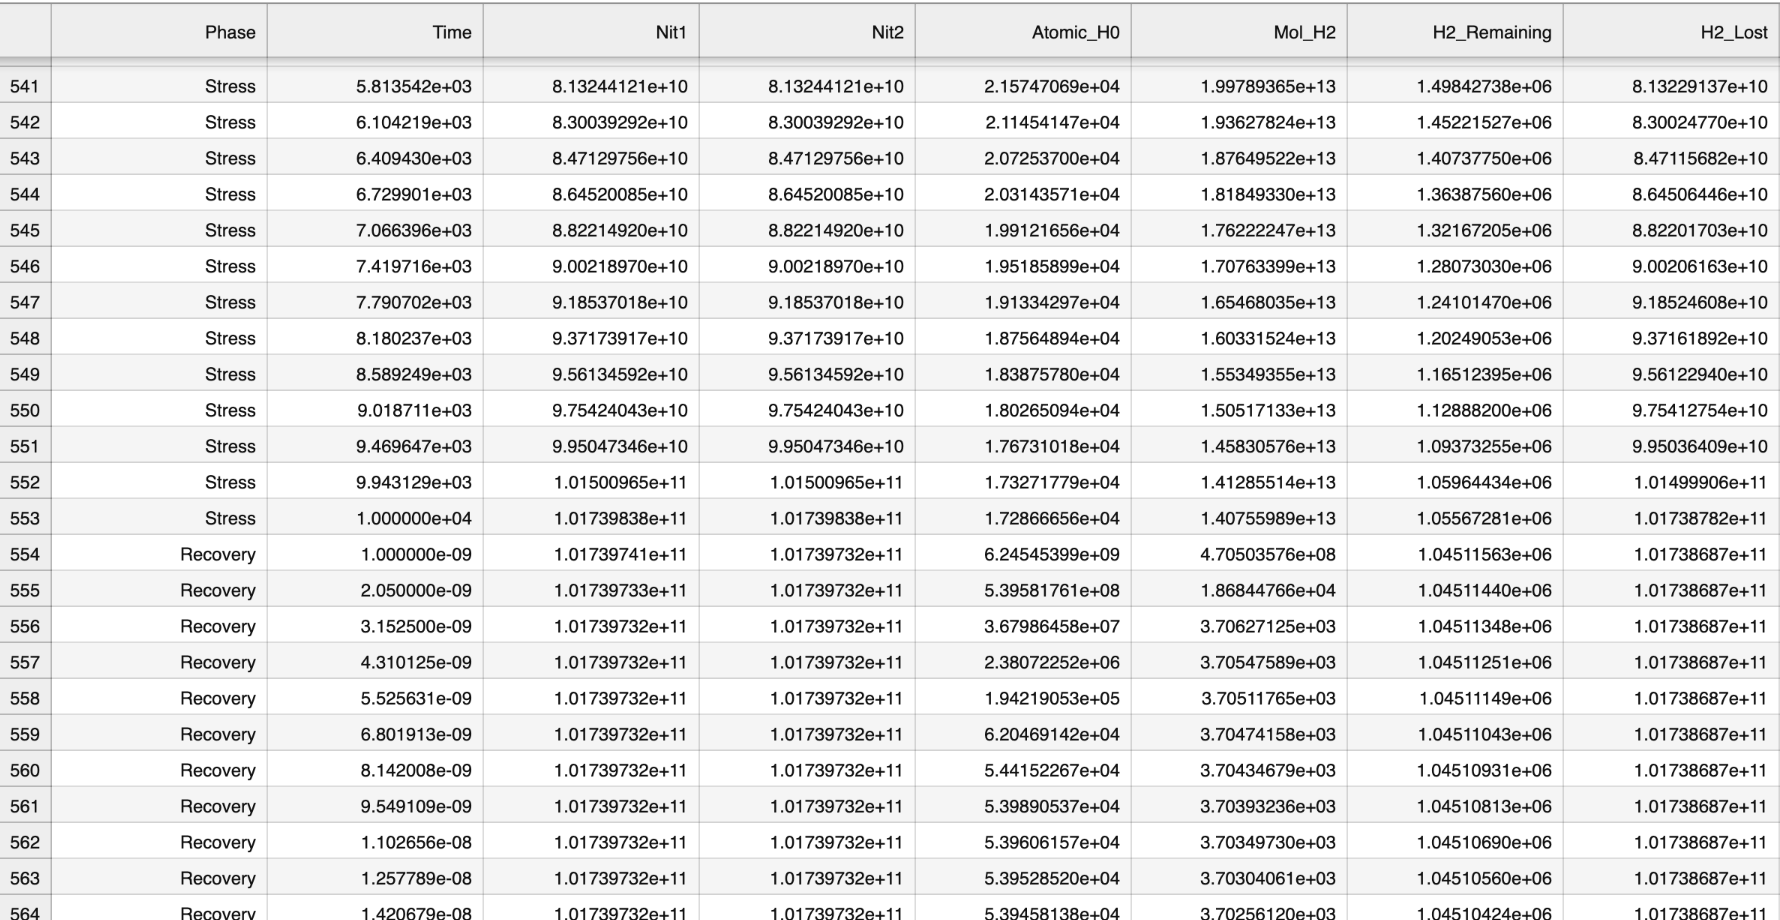
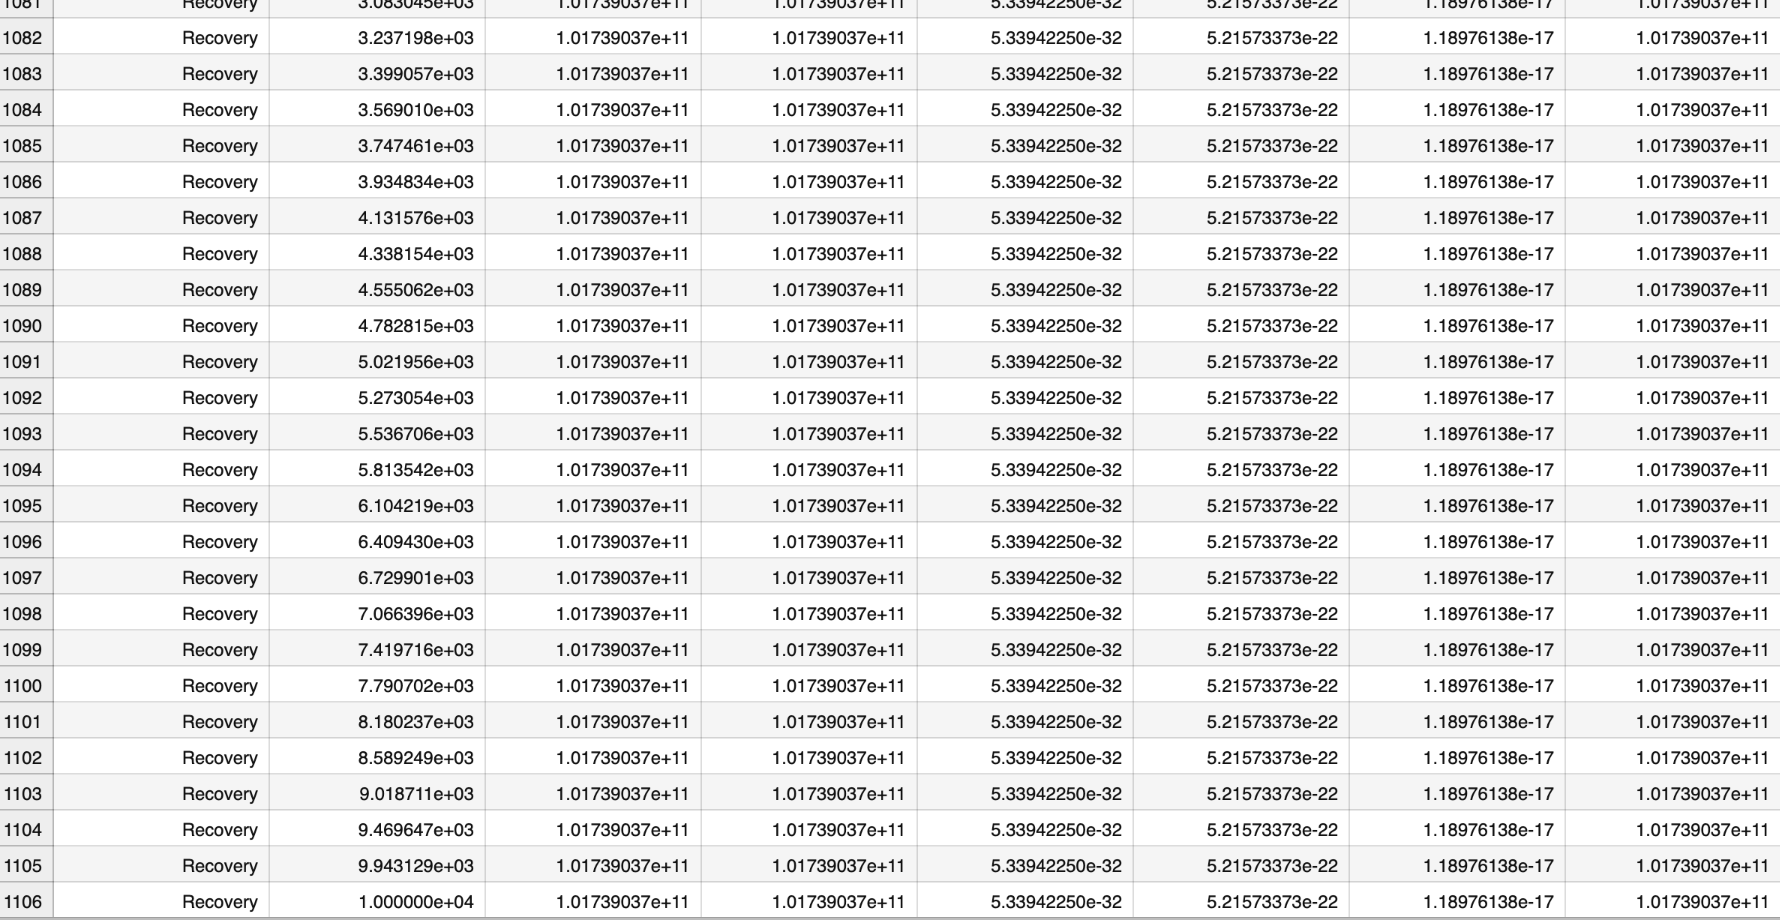

## PLots 
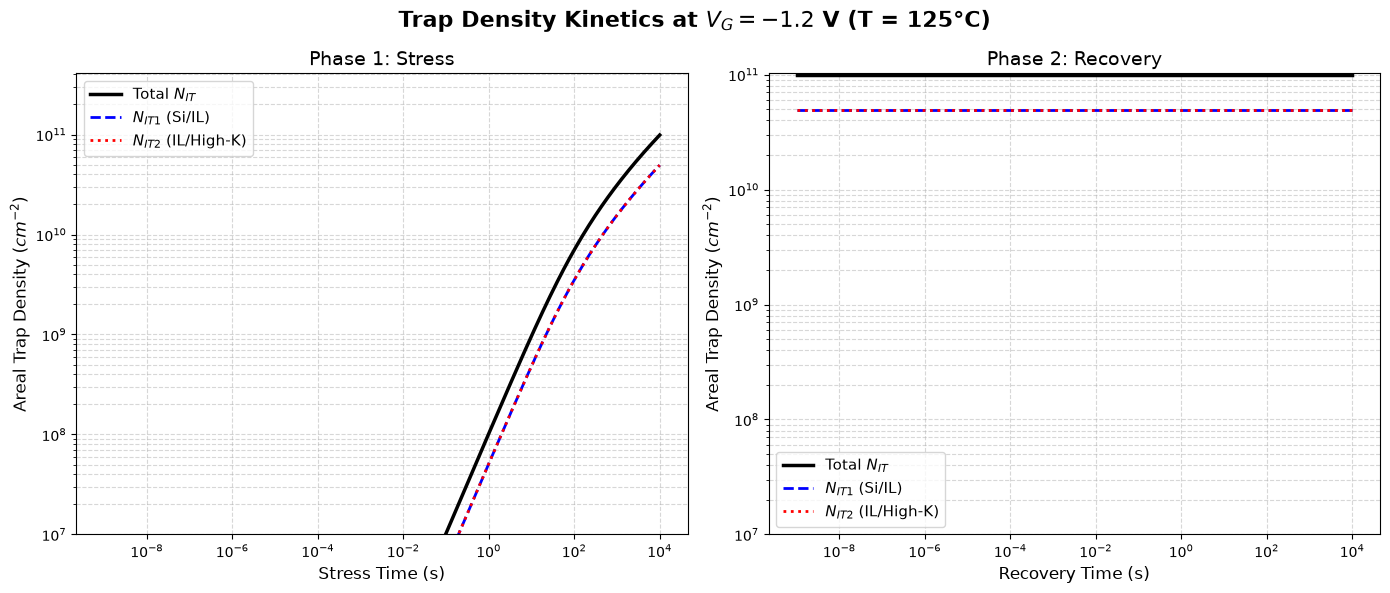
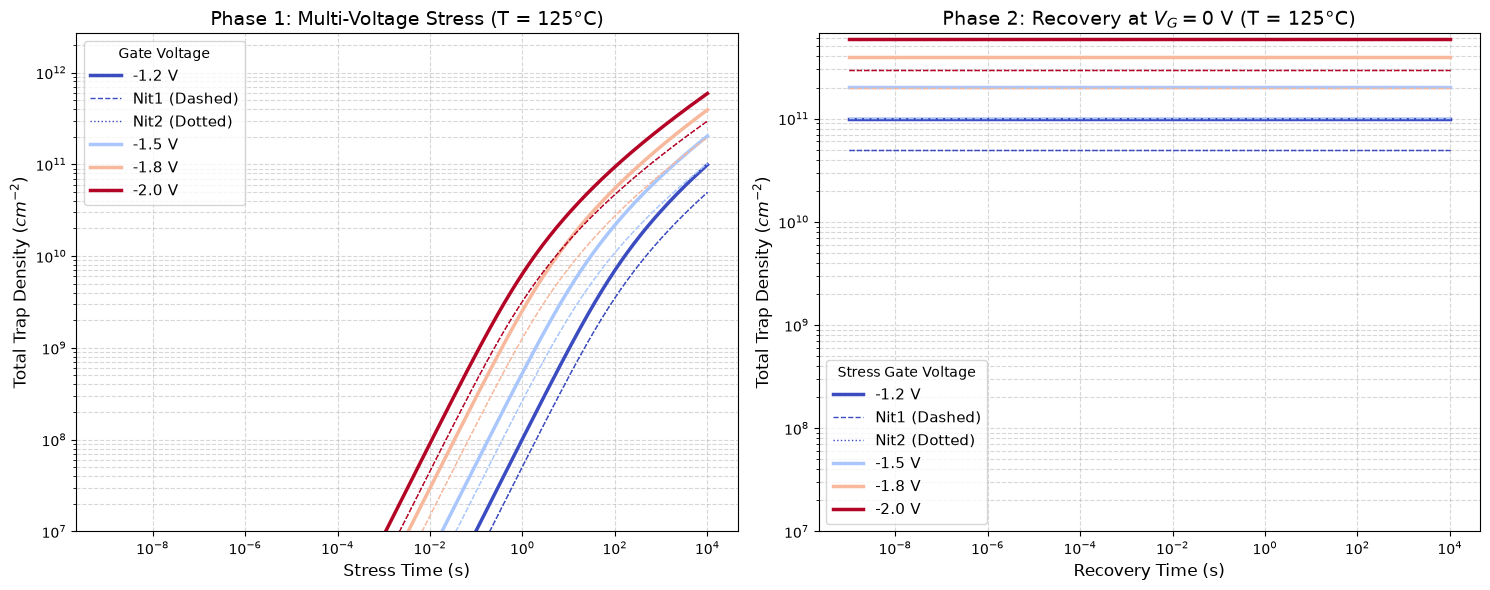
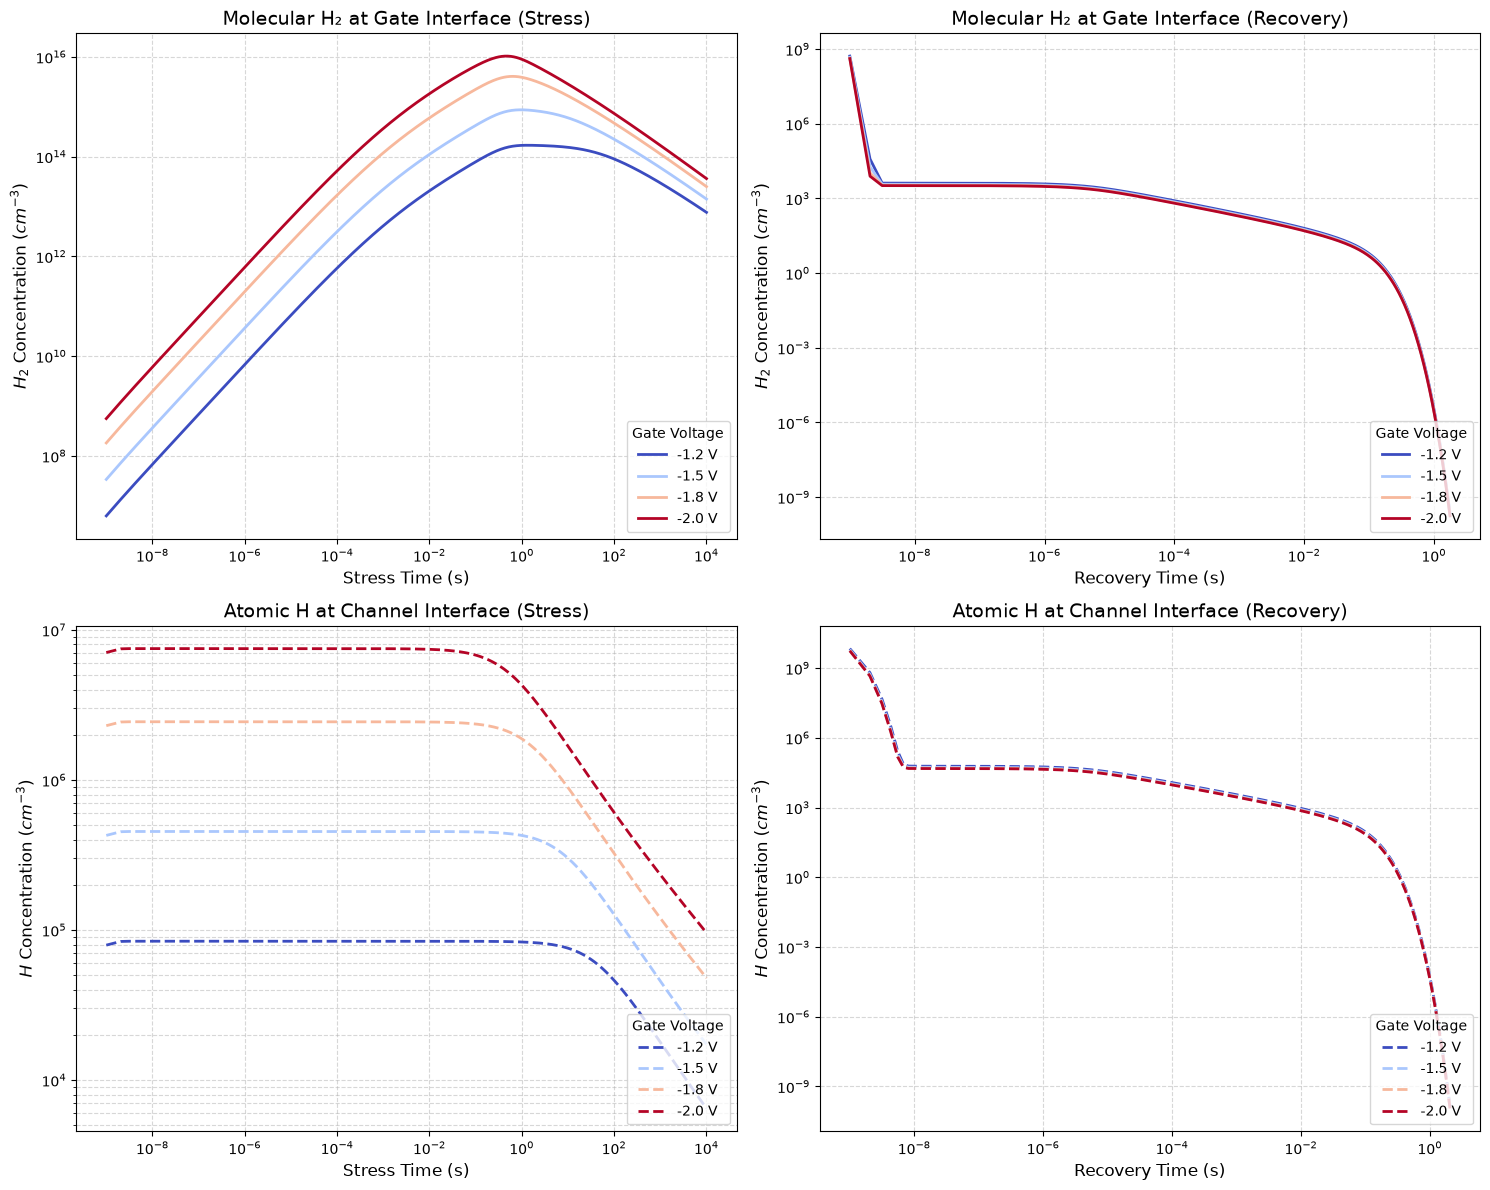
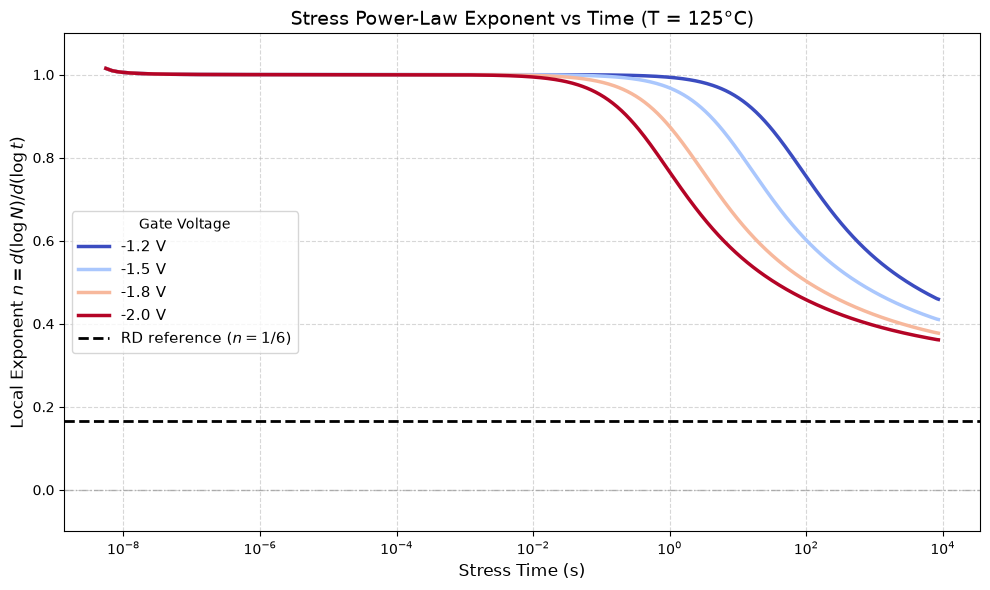

### Long-Time Simulation Results (The figures below show the results obtained from the long-time simulation. No idea about the interpretations)
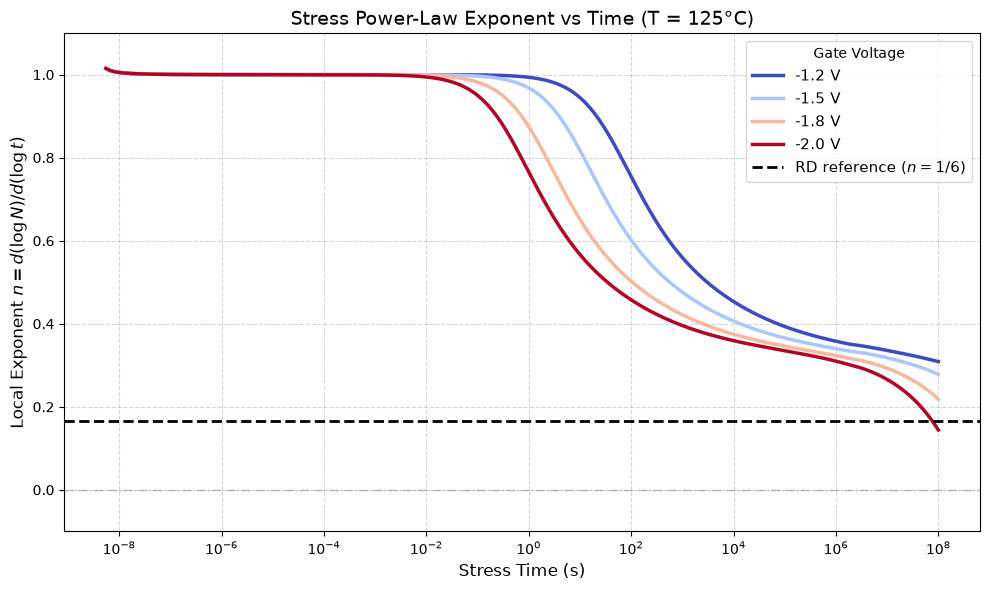


## Reflective H$_2$ Boundary Condition — Same Configuration
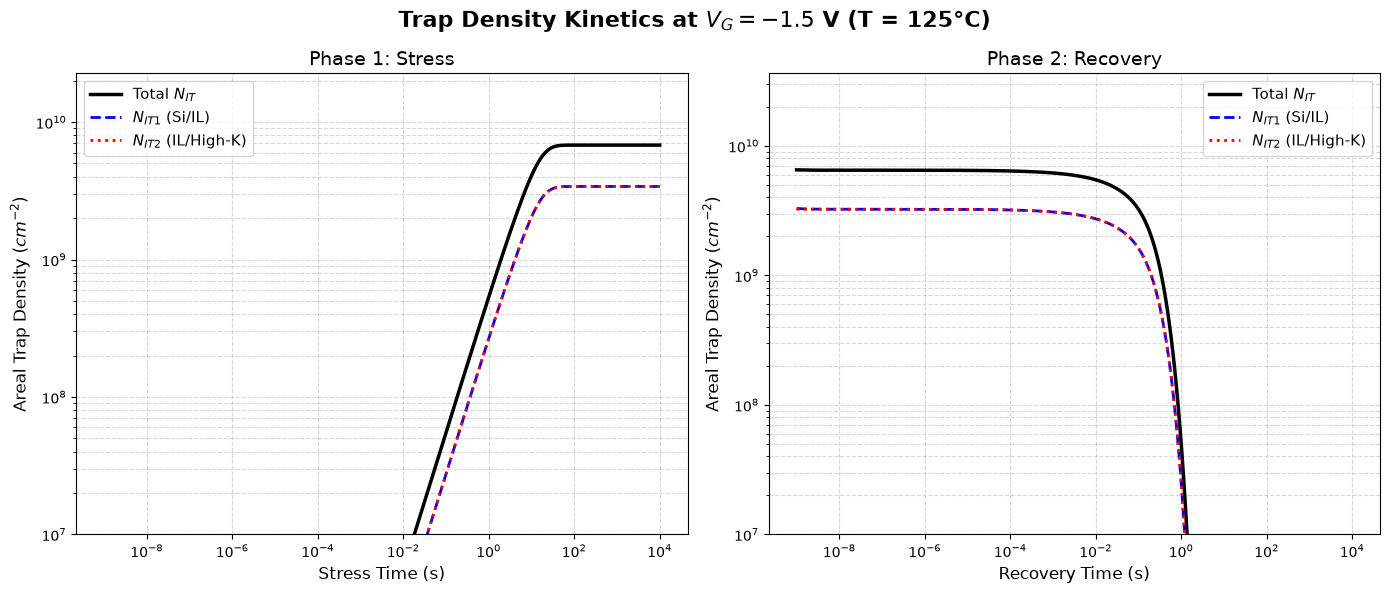
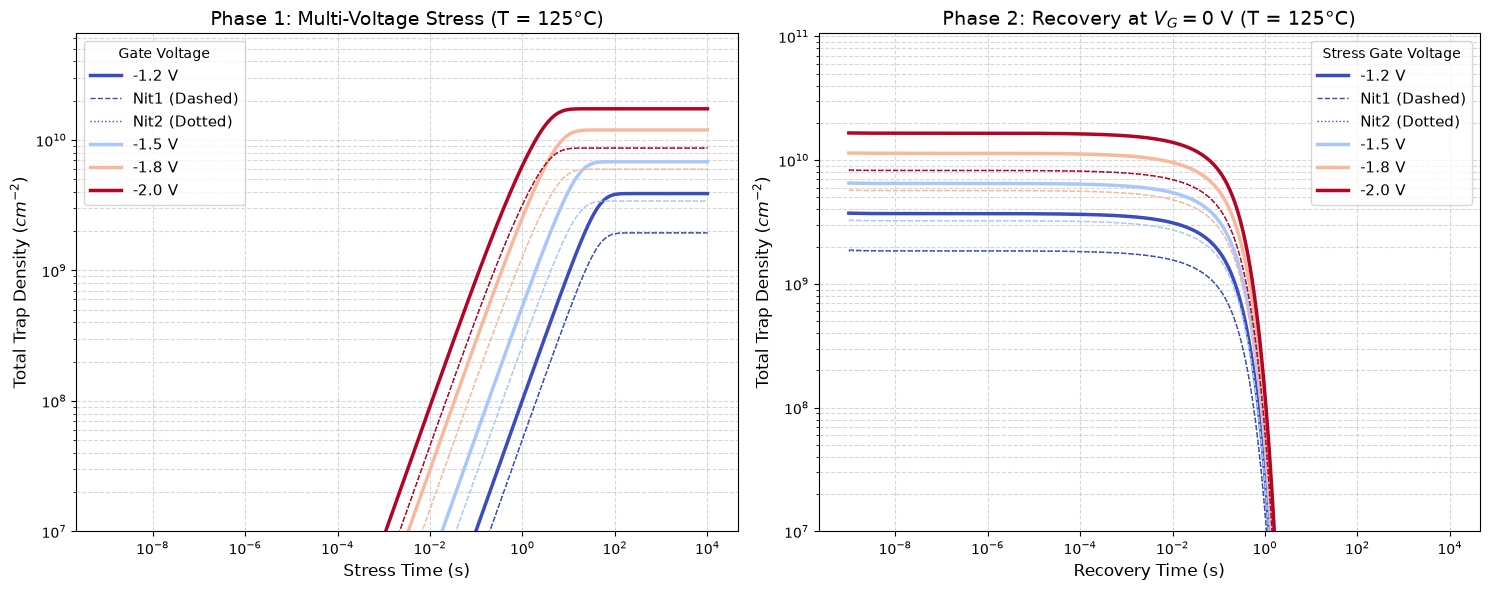
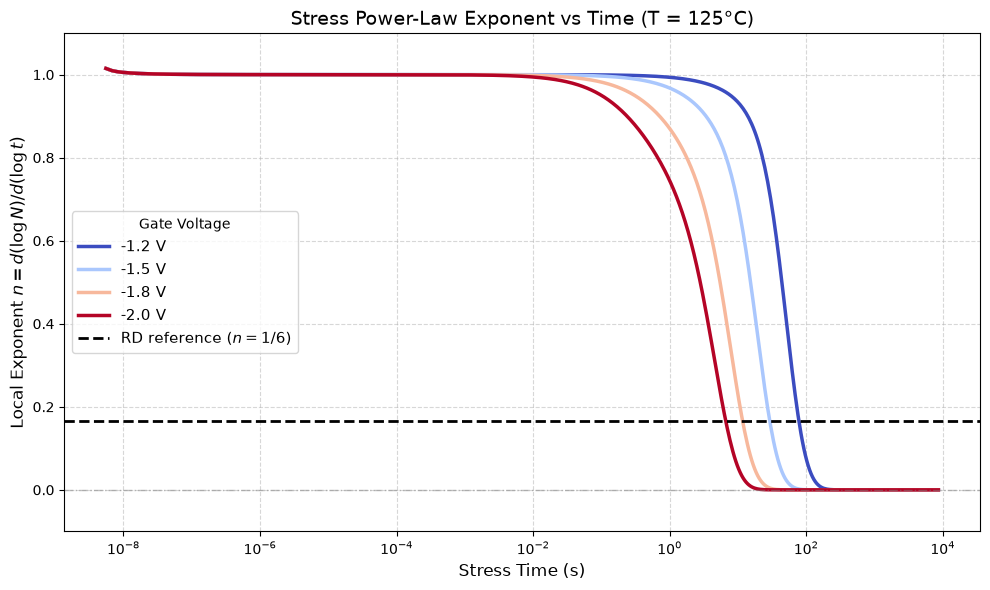

## 6. Conclusion

The coupled reaction–diffusion model was implemented using a fully coupled Newton–Raphson formulation to simultaneously solve the atomic-H concentration in the interlayer, molecular-H diffusion in the High-k layer, and the two interface-trap densities. Since the coupled Newton–Raphson solution is computationally more demanding than the previous iterative approach, parallel execution using native PThreads was utilized to run the simulations at different temperatures concurrently. The implementation was tested for both absorbing and reflective H2 boundary conditions, followed by long-time simulations and a voltage-dependent analysis.

The stress simulations show an increase in the interface-trap densities with stress time, while the recovery simulations show a reduction in the trap densities after the stress bias is removed. The atomic-H and molecular-H concentrations also evolve consistently with the coupled reaction–diffusion process. In the reflective H2 case, molecular hydrogen is retained within the High-k region rather than being removed through the gate-side boundary, resulting in a different long-time trap-generation and recovery behavior compared with the absorbing case.

Long-time simulations were also performed to examine the evolution of the trap density over an extended time range. The results show continued trap generation at long stress times, with the rate of increase gradually slowing as the system evolves. During recovery, the trap density decreases as the reverse reactions become active.

A voltage-dependent analysis was performed at 125 °C for gate voltages of -1.2, -1.5, -1.8, and -2.0 V. The calculated electric field increases with increasing magnitude of the negative gate voltage, and the simulations show a corresponding change in the trap-generation kinetics. The higher-magnitude gate voltages produce a faster stress response and shift the characteristic evolution of the trap density toward earlier times.

**Overall, the present work establishes a working numerical framework for studying coupled hydrogen transport, interface-trap generation, and recovery in the RD model. The results obtained so far reproduce the expected qualitative trends of stress, recovery, boundary-condition dependence, long-time evolution, and voltage dependence. However, the implementation is still under numerical debugging and validation, particularly with respect to the quantitative consistency of the coupled equations, boundary-condition treatment, and long-time behavior. Therefore, the present results should be regarded as an ongoing validation of the implementation rather than a final quantitative validation of the RD model.**

## 7. Code Repository

The current implementation and associated simulation/analysis files have been organized in a GitHub repository for reproducibility and further development.(Plz check folder-Phase-2)

The repository contains the current C implementation of the coupled reaction–diffusion model, simulation configurations, and analysis/plotting files. The code is still being actively debugged and refined as the numerical validation progresses.